# Evaluación 3

---



**Autores:**

1. Brian Chávez
2. Carlos Soto





**Correos Electrónicos:**


1. bria.chavez@duocuc.cl
2. car.sotoa@duocuc.cl


**Fecha de Creación:** Enero 2026

**Versión:** 1.0  



---

## Descripción

Este notebook corresponde al desarrollo de la entrega 3 de la asignatura Minería de Datos en el TAV de DuocUC - Sede Concepción

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.9.

A continuación se listan las bibliotecas necesarias:

-
    pandas
-
    numpy
-
    matplotlib
-
    seaborn
-
    scikit-learn

Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```bash
import pandas as pd
print(pd.__version__)
````

## Requisitos del notebook
1. Notebook bien estructurado, con secciones claramente numeradas.
2. Claridad, orden y coherencia en el desarrollo, evitando redundancia y repeticiones de código.
3. Preparación de los datos correctamente implementada mediante el uso de pipelines.
4. Justificación adecuada de la exclusión de variables sospechosas de inflar métricas.
5. Aplicación de un método consistente y fundamentado de selección de variables.
6. Construcción correcta, mediante pipeline, de un modelo de regresión sin ventana de tiempo.
7. Construcción correcta, mediante pipeline, de un modelo de regresión con ventana de tiempo.
8. Cálculo correcto de todas las métricas solicitadas para los modelos de regresión.
9. Interpretación correcta, en términos de negocio, de las métricas de uno de los modelos de regresión.
10. Realización de predicciones con datos simulados de forma aleatoria utilizando uno de los modelos de regresión.
11. Construcción correcta, mediante pipeline, de un modelo de clasificación utilizando ventana de tiempo y Regresión Logística.
12. Construcción correcta, mediante pipeline, de un modelo de clasificación utilizando ventana de tiempo y Árbol de Decisión.
13. Construcción correcta, mediante pipeline, de un modelo de clasificación utilizando SVM con el kernel adecuado.
14. Aplicación correcta de GridSearchCV considerando explícitamente el desbalance de clases.
15. Cálculo correcto de todas las métricas solicitadas para los modelos de clasificación.
16. Presentación correcta de la matriz de confusión para cada uno de los modelos.
17. Análisis del sobreentrenamiento (comparación train versus test) para todos los modelos de aprendizaje supervisado.
18. Interpretación correcta de las métricas solicitadas de uno de los modelos de regresión.
19. Selección de una métrica para los modelos de clasificación y justificación adecuada de dicha elección.
20. Selección automática del mejor modelo de clasificación en función de la métrica definida.
21. Interpretación de las métricas del mejor modelo de clasificación seleccionado, utilizando lenguaje de negocio.
22. Realización de predicciones con datos simulados de forma aleatoria utilizando el mejor modelo de clasificación.
23. Aplicación de técnicas de segmentación mediante KMeans para la identificación de patrones climáticos.
24. Descripción correcta e interpretación de los patrones climáticos identificados.


## Penalizaciones

- Ausencia de buenas prácticas en el notebook (imports fuera del inicio del notebook y/o presencia de warnings) (10%).
- Al menos dos resultados presentados sin interpretación en términos de negocio (10%).
- Falta de modelos solicitados o modelos que no cumplen con los rendimientos mínimos esperados (15%).
- Falta de uso de pipelines en la construcción de modelos predictivos (10%).
- Desconocimiento o falta de tratamiento del desbalance de clases en modelos de clasificación (10%).
- Presencia de fuga de información en la construcción o evaluación de los modelos (15%).
- Uso de KMeans considerando un valor fijo para K, sin justificación ni método de selección (10%).
- Faltas en la estructura del notebook, incluyendo ortografía, redacción y orden general del contenido (10%).



In [1]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/refs/heads/main/data_clima/data_clima_2025_final.csv

--2026-01-26 12:25:44--  https://raw.githubusercontent.com/JaznaLaProfe/datos/refs/heads/main/data_clima/data_clima_2025_final.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4527300 (4.3M) [text/plain]
Saving to: ‘data_clima_2025_final.csv’

data_clima_2025_fin 100%[===================>]   4.32M  26.0MB/s    in 0.2s    

2026-01-26 12:25:45 (26.0 MB/s) - ‘data_clima_2025_final.csv’ saved [4527300/4527300]



In [2]:
!pip install kneed

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import random

from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay,silhouette_score,accuracy_score, precision_score, recall_score, f1_score,roc_auc_score

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.svm import SVC

from sklearn.cluster import KMeans

from kneed import KneeLocator
from sklearn.decomposition import PCA




In [4]:
data = pd.read_csv('data_clima_2025_final.csv')
data.head()

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.1,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.9,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.4,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.9,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.4,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33024 entries, 0 to 33023
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  33024 non-null  object 
 1   temperature_2m        33024 non-null  float64
 2   relative_humidity_2m  33024 non-null  float64
 3   apparent_temperature  33024 non-null  float64
 4   precipitation         33024 non-null  float64
 5   cloud_cover           33024 non-null  float64
 6   wind_speed_10m        33024 non-null  float64
 7   wind_direction_10m    33024 non-null  float64
 8   rain                  33024 non-null  float64
 9   is_day                33024 non-null  float64
 10  sunshine_duration     33024 non-null  float64
 11  Localidad             33024 non-null  object 
 12  latitud               33024 non-null  float64
 13  longitud              33024 non-null  float64
 14  is_rainy_hour         33024 non-null  int64  
dtypes: float64(12), int

#     1.0 Preparación de los datos

Llamada de clase winsorizer

In [6]:
#Clase del winsorizer, esto se carga antes de ocuparla en el Pipeline
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):
        # Guardar nombres si es DataFrame, si no generar nombres genéricos
        if isinstance(X, pd.DataFrame):
            self.columns_ = X.columns
        else:
            self.columns_ = np.arange(X.shape[1])
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_)
        for col in self.columns_:
            lower = X[col].quantile(self.limits[0])
            upper = X[col].quantile(1 - self.limits[1])
            X[col] = np.clip(X[col], lower, upper)
        return X.values

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(self.columns_)
        else:
            return np.array(input_features)

Conversión de date

In [7]:
# Convertir la columna 'date' a datetime
data['date'] = pd.to_datetime(data['date'])

# Extraer hora
data['hour'] = data['date'].dt.hour

# Extraer mes
data['month'] = data['date'].dt.month

# Extraer día del mes
data['day'] = data['date'].dt.day

# Extraer año
data['year'] = data['date'].dt.year

Ventanas de tiempo

In [8]:
window = 5

variables_climaticas = [
    'temperature_2m',
    'relative_humidity_2m',
    'cloud_cover',
    'precipitation',
    'rain',

    #variables agregadas nuevas para que el f1 score de
    'apparent_temperature',
    'sunshine_duration',
]

# Asegurar que 'date' sea de tipo datetime y ordenar para operaciones de ventana
data['date'] = pd.to_datetime(data['date'])
# Extraer 'hour', 'month', 'day' para asegurar que estén disponibles en 'data'
data['hour'] = data['date'].dt.hour
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day

# Convertir columnas tipo booleano a int para consistencia si se usan como categóricas más tarde
# Asegurar que estas columnas existan antes de intentar convertirlas o usarlas
if 'is_day' in data.columns:
    data['is_day'] = data['is_day'].astype(int)
if 'is_rainy_hour' in data.columns:
    data['is_rainy_hour'] = data['is_rainy_hour'].astype(int)

data = data.sort_values(['Localidad', 'date'])

dfs_por_localidad = {}

for localidad, df_loc_original in data.groupby('Localidad'):
    df_loc_original = df_loc_original.sort_values('date').reset_index(drop=True)

    # Inicializar un nuevo DataFrame para las características procesadas para esta localidad
    # La longitud será original_length - window + 1 después de la ventana
    processed_data_length = len(df_loc_original) - window + 1
    if processed_data_length <= 0:
        continue # Omitir si no hay suficientes datos para la ventana

    # Crear un DataFrame base para almacenar las características procesadas, asegurando que las columnas estén alineadas
    processed_df_loc = pd.DataFrame({
        'Localidad': [localidad] * processed_data_length,
        'month': df_loc_original['month'].iloc[window - 1:].values,
        'day': df_loc_original['day'].iloc[window - 1:].values,
        'hour': df_loc_original['hour'].iloc[window - 1:].values,
        'is_day': df_loc_original['is_day'].iloc[window - 1:].values,
        'is_rainy_hour': df_loc_original['is_rainy_hour'].iloc[window - 1:].values
    })

    for v in variables_climaticas:
        # Valor actual al final de la ventana
        processed_df_loc[f"{v}_actual"] = df_loc_original[v].iloc[window - 1:].values

        # Estadísticas de la ventana rodante
        rolling_stats = df_loc_original[v].rolling(window=window, min_periods=window)
        # Asegurar la alineación tomando valores desde window-1 hasta el final
        processed_df_loc[f"{v}_mean"] = rolling_stats.mean().iloc[window - 1:].values
        processed_df_loc[f"{v}_max"] = rolling_stats.max().iloc[window - 1:].values
        processed_df_loc[f"{v}_min"] = rolling_stats.min().iloc[window - 1:].values

    # Ordenar nuevamente si es necesario, aunque ya debería estar ordenado por componentes de fecha/hora
    dfs_por_localidad[localidad] = processed_df_loc.sort_values(['month', 'day', 'hour']).reset_index(drop=True)




Variables categoricas

In [9]:
# Características categóricas: 'Localidad', 'is_day', 'is_rainy_hour', 'day'.
# 'hour' y 'month' se manejan por separado con cyclical_features.
features_cat = ['Localidad', 'is_day', 'is_rainy_hour', 'day']

Variables numericas

In [10]:
features_num = [
    'temperature_2m_actual', 'relative_humidity_2m_actual', 'cloud_cover_actual',
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'relative_humidity_2m_mean', 'relative_humidity_2m_max', 'relative_humidity_2m_min',
    'cloud_cover_mean', 'cloud_cover_max', 'cloud_cover_min',
    'apparent_temperature_actual', 'sunshine_duration_actual',
    'apparent_temperature_mean', 'apparent_temperature_max', 'apparent_temperature_min',
    'sunshine_duration_mean', 'sunshine_duration_max', 'sunshine_duration_min',
    'precipitation_actual', 'precipitation_mean', 'precipitation_max', 'precipitation_min',
    'rain_actual', 'rain_mean', 'rain_max', 'rain_min'
]

Transformación ciclica

In [11]:
class CyclicalFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, max_value):
        self.max_value = max_value

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Acá aplica la fórmula ya explicada
        sin = np.sin(2 * np.pi * X / self.max_value)
        cos = np.cos(2 * np.pi * X / self.max_value)
        return np.c_[sin, cos]

cyclical_features = ColumnTransformer(
    transformers=[
        ("hour", CyclicalFeatures(24), ["hour"]),
        ("month", CyclicalFeatures(12), ["month"])
    ],
    remainder="drop"
)

time_pipeline = Pipeline(steps=[
    ("cyclical", cyclical_features),
    ("scaler", StandardScaler())
])

X_time = time_pipeline.fit_transform(data)
X_time.shape

columns_name = [
    "hour_sin", "hour_cos",
    "month_sin", "month_cos"
]



Pipeline

In [12]:
# Pipeline numérico con Winsorizer
tratamiento_numericas = Pipeline(steps=[
    ("winsorizer", Winsorizer(limits=(0.05, 0.05))),
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
tratamiento_categoricas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Combina en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", tratamiento_numericas, features_num),
        ("cat", tratamiento_categoricas, features_cat),
        ("time", cyclical_features, ["hour", "month"])
    ]
)


In [13]:
# Crea el pipeline final (preprocesamiento)
preprocesamiento = Pipeline(steps=[
    ("preprocessor", preprocessor)
])

In [14]:
# Concatenar todos los dataframes de dfs_por_localidad en un único dataframe
data_for_pipeline = pd.concat(dfs_por_localidad.values(), ignore_index=True)

# Aplicar el pipeline de preprocesamiento al dataframe combinado
X_preparada = preprocesamiento.fit_transform(data_for_pipeline)
X_preparada.shape

(33008, 67)

In [15]:
# Composición del proceso
preprocesamiento

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['temperature_2m_actual',
                                                   'relative_humidity_2m_actual',
                                                   'cloud_cover_actual',
                                                   'temperature_2m_mean',
                                                   'temperature_2m_max',
                                                   'temperature_2m_min',
                                                   'relative_humidity_2m_mean',
                                                   'relative...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Localidad', 'is_day',
                                                   'is_rainy_hour', 'day']),
                                                 ('time',
                                                  ColumnTransformer(transformers=[('hour',
                                                                                   CyclicalFeatures(max_value=24),
                                                                                   ['hour']),
                                                                                  ('month',
                                                                                   CyclicalFeatures(max_value=12),
                                                                                   ['month'])]),
                                                  ['hour', 'month'])]))])

In [16]:
pd.DataFrame(X_preparada)

,0,1,2,3,4,5,6,7,8,9,...,57,58,59,60,61,62,63,64,65,66
0,0.589208,-0.561102,-1.484396,0.804869,0.642428,0.944406,-0.842016,-1.041545,-0.635727,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.965926,-0.258819,5.000000e-01,0.866025
1,0.484369,-0.056782,-1.484396,0.710283,0.602846,0.827929,-0.752328,-0.530286,-0.635727,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.866025,-0.500000,5.000000e-01,0.866025
2,0.379530,0.576254,-1.484396,0.602798,0.503892,0.711452,-0.421597,0.239273,-0.635727,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.707107,-0.707107,5.000000e-01,0.866025
3,0.306143,0.849110,-1.484396,0.501762,0.404937,0.629918,-0.012989,0.570974,-0.453677,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.500000,-0.866025,5.000000e-01,0.866025
4,0.578724,0.393792,-1.484396,0.478116,0.305983,0.629918,0.257189,0.570974,-0.160589,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.258819,-0.965926,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33003,2.015015,-1.824701,0.880500,1.985052,1.994638,1.934459,-2.054359,-2.237867,-1.716447,-1.087762,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.500000,0.866025,-2.449294e-16,1.000000
33004,1.857757,-1.548220,0.904388,1.985052,1.994638,1.934459,-2.054359,-2.237867,-1.716447,-0.561355,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.258819,0.965926,-2.449294e-16,1.000000
33005,1.564208,-1.095305,0.044426,1.985052,1.849670,1.934459,-1.875604,-1.792779,-1.702748,-0.229718,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,-2.449294e-16,1.000000
33006,1.375498,-0.695991,-0.839424,1.841022,1.770507,1.817982,-1.554271,-1.307347,-1.633121,-0.092853,...,0.0,0.0,0.0,0.0,0.0,0.0,0.258819,0.965926,-2.449294e-16,1.000000


In [17]:
num_cols = features_num
cat_cols = preprocesamiento.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["encoder"] \
    .get_feature_names_out(features_cat)

# Añadir los nombres de las columnas de la transformación cíclica
all_columns = list(num_cols) + list(cat_cols) + columns_name

data_preparada = pd.DataFrame(X_preparada, columns=all_columns)

#Información de la data preparada

In [18]:
data_preparada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33008 entries, 0 to 33007
Data columns (total 67 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   temperature_2m_actual          33008 non-null  float64
 1   relative_humidity_2m_actual    33008 non-null  float64
 2   cloud_cover_actual             33008 non-null  float64
 3   temperature_2m_mean            33008 non-null  float64
 4   temperature_2m_max             33008 non-null  float64
 5   temperature_2m_min             33008 non-null  float64
 6   relative_humidity_2m_mean      33008 non-null  float64
 7   relative_humidity_2m_max       33008 non-null  float64
 8   relative_humidity_2m_min       33008 non-null  float64
 9   cloud_cover_mean               33008 non-null  float64
 10  cloud_cover_max                33008 non-null  float64
 11  cloud_cover_min                33008 non-null  float64
 12  apparent_temperature_actual    33008 non-null 

# 2.0  Modelos de regresión

#### Modelo de regresión sin ventana

In [ ]:
# Variables numéricas
features_num = [
    "temperature_2m_actual",
    "cloud_cover_actual",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos"
]

# Variables day transformadas con one-hot-encoder
features_day = [col for col in data_preparada.columns if col.startswith("day_")]

# Variables categóricas ya codificadas
features_cat = [
    "is_day_1",
    "is_rainy_hour_1",
    "Localidad_Punta Arenas, Chile",
    "Localidad_Temuco, Chile",
    "Localidad_Valdivia, Chile"
]

# Features finales
features = features_num + features_day + features_cat

X = data_preparada[features]
y = data_preparada["relative_humidity_2m_actual"]

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_num + features_day),
        ("cat", "passthrough", features_cat)
    ]
)


In [ ]:
# Calcula la matriz de correlaciones
correlaciones = data_preparada.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones["relative_humidity_2m_actual"].sort_values(ascending=False)

correlacion_objetivo

,relative_humidity_2m_actual
relative_humidity_2m_actual,1.000000
relative_humidity_2m_mean,0.887257
relative_humidity_2m_min,0.885688
relative_humidity_2m_max,0.820988
hour_sin,0.575741
...,...
is_day_1,-0.522606
sunshine_duration_min,-0.624782
sunshine_duration_max,-0.629475
sunshine_duration_actual,-0.687092


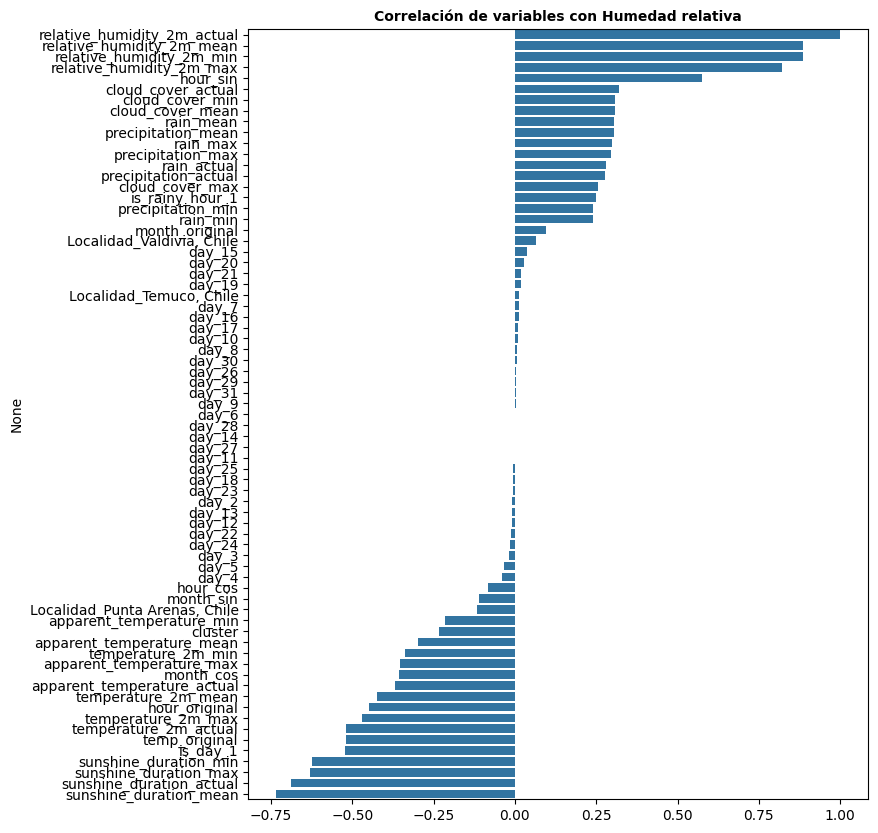

In [ ]:
# Visualización de las correlaciones con el objetivo
plt.figure(figsize=(8,10))
sns.barplot(x=correlacion_objetivo.values, y=correlacion_objetivo.index)
plt.title("Correlación de variables con Humedad relativa",
          fontsize=10, fontweight="bold")
plt.show()


In [ ]:
# Crea el pipeline del modelo de regresión sin ventana
modelo = Pipeline(steps=[
    ("regressor", LinearRegression())
])

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

feature_names = X.columns.tolist()

# Entrenamiento
modelo.fit(X_train, y_train)



Pipeline(steps=[('regressor', LinearRegression())])

In [ ]:
# Variables con las cuales fue entrenado el modelo
modelo.feature_names_in_

array(['temperature_2m_actual', 'cloud_cover_actual', 'hour_sin',
       'hour_cos', 'month_sin', 'month_cos', 'day_2', 'day_3', 'day_4',
       'day_5', 'day_6', 'day_7', 'day_8', 'day_9', 'day_10', 'day_11',
       'day_12', 'day_13', 'day_14', 'day_15', 'day_16', 'day_17',
       'day_18', 'day_19', 'day_20', 'day_21', 'day_22', 'day_23',
       'day_24', 'day_25', 'day_26', 'day_27', 'day_28', 'day_29',
       'day_30', 'day_31', 'is_day_1', 'is_rainy_hour_1',
       'Localidad_Punta Arenas, Chile', 'Localidad_Temuco, Chile',
       'Localidad_Valdivia, Chile'], dtype=object)

#### Métricas sin ventana

In [ ]:
# Métricas del modelo de regresión sin ventana

y_pred = modelo.predict(X_test)

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas del modelo ---")
print(f"{'R²' :<15}: {r2:.3}")
print(f"{'MAE':<15}: {mae:,.3} % Humedad")


--- Métricas del modelo ---
R²             : 0.667
MAE            : 0.455 % Humedad


### Modelo de regresión (Ventana)

In [ ]:
# Variables numéricas
features_num_ventana = [
    "relative_humidity_2m_mean",
    "relative_humidity_2m_min",
    "relative_humidity_2m_max",
    "temperature_2m_actual",
    "temperature_2m_mean",
    "temperature_2m_min",
    "temperature_2m_max",
    "cloud_cover_mean",
    "cloud_cover_min",
    "cloud_cover_max",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos"
]

# Variables day transformadas con one-hot-encoder
features_day_ventana = [col for col in data.columns if col.startswith("day_")]

# Variables categóricas ya codificadas
features_cat_ventana = [
    "is_day_1",
    "is_rainy_hour_1",
    "Localidad_Punta Arenas, Chile",
    "Localidad_Temuco, Chile",
    "Localidad_Valdivia, Chile"
]

# Features finales
features = features_num_ventana + features_day_ventana + features_cat_ventana

X = data_preparada[features]
y = data_preparada["relative_humidity_2m_actual"]

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_num_ventana + features_day_ventana),
        ("cat", "passthrough", features_cat_ventana)
    ]
)


In [ ]:
# Calcula la matriz de correlaciones
correlaciones_ventana = data_preparada.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo_ventana = correlaciones_ventana["relative_humidity_2m_actual"].sort_values(ascending=False)

correlacion_objetivo_ventana

,relative_humidity_2m_actual
relative_humidity_2m_actual,1.000000
relative_humidity_2m_mean,0.887257
relative_humidity_2m_min,0.885688
relative_humidity_2m_max,0.820988
hour_sin,0.575741
...,...
is_day_1,-0.522606
sunshine_duration_min,-0.624782
sunshine_duration_max,-0.629475
sunshine_duration_actual,-0.687092


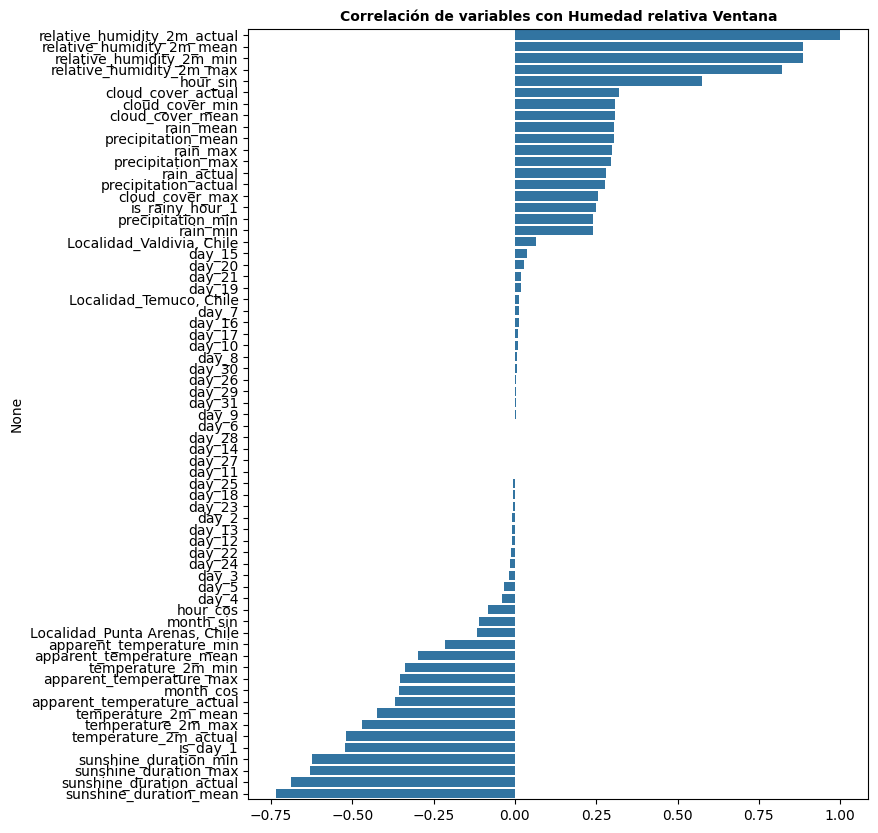

In [ ]:
# Visualización de las correlaciones con el objetivo
plt.figure(figsize=(8,10))
sns.barplot(x=correlacion_objetivo_ventana.values, y=correlacion_objetivo_ventana.index)
plt.title("Correlación de variables con Humedad relativa Ventana",
          fontsize=10, fontweight="bold")
plt.show()

In [ ]:
# Crea el pipeline final (modelo CON VENTANA)
modelo_ventana = Pipeline(steps=[
    ("regressor", LinearRegression())
])

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

feature_names = X.columns.tolist()

# Entrenamiento
modelo_ventana.fit(X_train, y_train)

Pipeline(steps=[('regressor', LinearRegression())])

In [ ]:
# Variables con las cuales fue entrenado el modelo ventana
modelo_ventana.feature_names_in_

array(['relative_humidity_2m_mean', 'relative_humidity_2m_min',
       'relative_humidity_2m_max', 'temperature_2m_actual',
       'temperature_2m_mean', 'temperature_2m_min', 'temperature_2m_max',
       'cloud_cover_mean', 'cloud_cover_min', 'cloud_cover_max',
       'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_day_1',
       'is_rainy_hour_1', 'Localidad_Punta Arenas, Chile',
       'Localidad_Temuco, Chile', 'Localidad_Valdivia, Chile'],
      dtype=object)

In [ ]:
# Funciones para ayudar con la interpretación de las métricas
def interpretacion_ventana(algoritmo : str, score : float, contexto_ventana : str, caracteristicas : np.array = None):
  """
  Genera la interpretación del rendimiento del modelo
  """
  if not caracteristicas == None:
    return f"""Modelo de regresión {algoritmo}
    {score :.2%} de la variabilidad en {contexto_ventana} se puede explicar utilizando: {caracteristicas.values}."""
  else:
    return f"""Modelo de regresión {algoritmo}
      {score :.2%} de la variabilidad en {contexto_ventana} se puede explicar utilizando las variables independientes"""

def mae_interpretacion_ventana(value : float, contexto_ventana : str, modelo_ventana : str = "Modelo") -> str:
  """
  Genera la interpretación del MAE
  """
  return f"El modelo '{modelo_ventana}' pudo predecir {contexto_ventana} en el conjunto de prueba con un error de ± % {value:.2f} del porcentaje de humedad real."


#### Métricas ventana

In [ ]:
# Predicciones

y_pred = modelo_ventana.predict(X_test)

# Evaluación
mae_ventana = mean_absolute_error(y_test, y_pred)
r2_ventana = r2_score(y_test, y_pred)

print("\n--- Métricas del modelo ---")
print(f"{'R²' :<15}: {r2_ventana:.3}")
print(f"{'MAE':<15}: {mae_ventana:,.2} % Humedad")


--- Métricas del modelo ---
R²             : 0.944
MAE            : 0.18 % Humedad


In [ ]:
# Guarda las métricas para comparar después con una posible mejora
resultado_inicial = {"R2" : r2_ventana, "MAE" : mae_ventana}

In [ ]:
# Interpretación de las métricas R2
nombre_modelo = "Predicción porcentaje humedad ventana"
print(interpretacion_ventana(nombre_modelo, r2_ventana, "Porcentaje humedad"))

Modelo de regresión Predicción porcentaje humedad ventana
      94.44% de la variabilidad en Porcentaje humedad se puede explicar utilizando las variables independientes


In [ ]:
# Interpretación de las métricas MAE
print(mae_interpretacion_ventana(mae_ventana, "Porcentaje humedad", nombre_modelo))

El modelo 'Predicción porcentaje humedad ventana' pudo predecir Porcentaje humedad en el conjunto de prueba con un error de ± % 0.18 del porcentaje de humedad real.


#### Interpretación en el negocio del MAE y el R2

En este modelo de regresión, se está prediciendo la humedad relativa del ambiente, según nuestro modelo aplicando una ventana de 5 horas, se puede interpretar que existen un **margen de error o desvío en la prediccion de un  0.18% de la humedad relativa real (MAE)**, esto es **respaldado por un 94.4% de precisión en base a las variables escogidas (R2)**

- Aplicación en el caso de negocio:
Para nuestro caso de negocio (Negocio viajes en Parapente) , esta métrica puede ayudar a tomar diversas descisiones, como por ejemplo, si se predice una humedad relativa alta, por concepto, las nubes se generan a una altura más baja, por lo tanto, si se concreta un despliegue de vuelo en parapente , la nubosidad podría afectar significativamente la visibilidad del usuario, por lo tanto su seguridad se vería afectada, una predicción de humedad relativa en el negocio puede fidelizar viajes seguros y limpios de riesgo.

#### Predicción con datos al azar

In [ ]:
# Constante de ajuste
CONSTANTE_MAE = 0.18

# Seleccionar una fila aleatoria de los datos preparados
indice_aleatorio = np.random.randint(0, len(data_preparada))

# Extraer la fila completa con todas las features
nueva_lectura = data_preparada.iloc[indice_aleatorio:indice_aleatorio+1]

# Realizar la predicción
humedad_estimada = modelo_ventana.predict(nueva_lectura[feature_names])[0]

# Asegurar que la humedad esté entre 0 y 100
humedad_estimada = np.clip(humedad_estimada, 0, 100)

# Obtener la humedad real para comparar (desde data original, no preparada)
humedad_real = data.iloc[indice_aleatorio]['relative_humidity_2m']

# Calcular humedades con la constante
humedad_con_suma = np.clip(humedad_real + CONSTANTE_MAE, 0, 100)
humedad_con_resta = np.clip(humedad_real - CONSTANTE_MAE, 0, 100)

# Obtener información adicional del dato original
fila_info = data.iloc[indice_aleatorio]
fecha = pd.to_datetime(fila_info['date'])
temperatura = data_preparada.iloc[indice_aleatorio]['temperature_2m_actual']
nubosidad = data_preparada.iloc[indice_aleatorio]['cloud_cover_actual']
localidad = fila_info['Localidad']

# Mostrar resultados
print(f"\n{'='*50}")
print(f"PREDICCIÓN DE HUMEDAD RELATIVA")
print(f"{'='*50}")
print(f"Fecha/Hora    : {fecha}")
print(f"Localidad     : {localidad}")
print(f"Temperatura   : {temperatura:.1f} °C")
print(f"Nubosidad     : {nubosidad:.0f} %")
print(f"{'-'*50}")
print(f"Humedad Real         : {humedad_real:.2f} %")
print(f"Humedad Predicha + 0.18% : {humedad_con_suma:.2f} %")
print(f"Humedad Predicha - 0.18% : {humedad_con_resta:.2f} %")


PREDICCIÓN DE HUMEDAD RELATIVA
Fecha/Hora    : 2025-09-28 16:00:00+00:00
Localidad     : Punta Arenas, Chile
Temperatura   : -1.4 °C
Nubosidad     : 0 %
--------------------------------------------------
Humedad Real         : 74.84 %
Humedad Predicha + 0.18% : 75.02 %
Humedad Predicha - 0.18% : 74.66 %


En esta predicción se puede interpretar que bajo una localidad del dataframe, la hora, la fecha, la temperatura y un porcentaje de nubosidad corresponden a una humedad relativa del ambiente, entonces la predicción según el MAE calculado se le suma el 0,18% o se le resta un 0,18%.

# 3.0 Modelos de clasificación

# 3.1 Evaluar fuga de información

Heatmap de correlación

In [ ]:
def get_correlation(
    data_preparada: pd.DataFrame,
    candidatas,
    visible: bool = True,
    size: tuple = (22, 18)
) -> pd.DataFrame:
    """
    Muestra un mapa de calor con la matriz completa de correlaciones
    entre las variables indicadas.

    Parámetros
    ----------
    data_preparada : pd.DataFrame
        DataFrame con los datos preparados
    candidatas : iterable
        Nombres de las variables a considerar
    visible : bool
        Mostrar o no el heatmap
    size : tuple
        Tamaño del gráfico

    Retorna
    -------
    pd.DataFrame
        Matriz de correlaciones
    """

    # Filtrar columnas válidas
    columnas = [c for c in candidatas if c in data_preparada.columns]

    # Calcular correlación
    corr = data_preparada[columnas].corr()

    if visible:
        plt.figure(figsize=size)
        sns.heatmap(
            corr,
            cmap="vlag",
            center=0,
            square=True,
            linewidths=0.3,
            cbar_kws={"shrink": 0.75}
        )
        plt.title(
            "Mapa de correlación (matriz completa)",
            fontsize=18,
            fontweight="bold"
        )
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    return corr


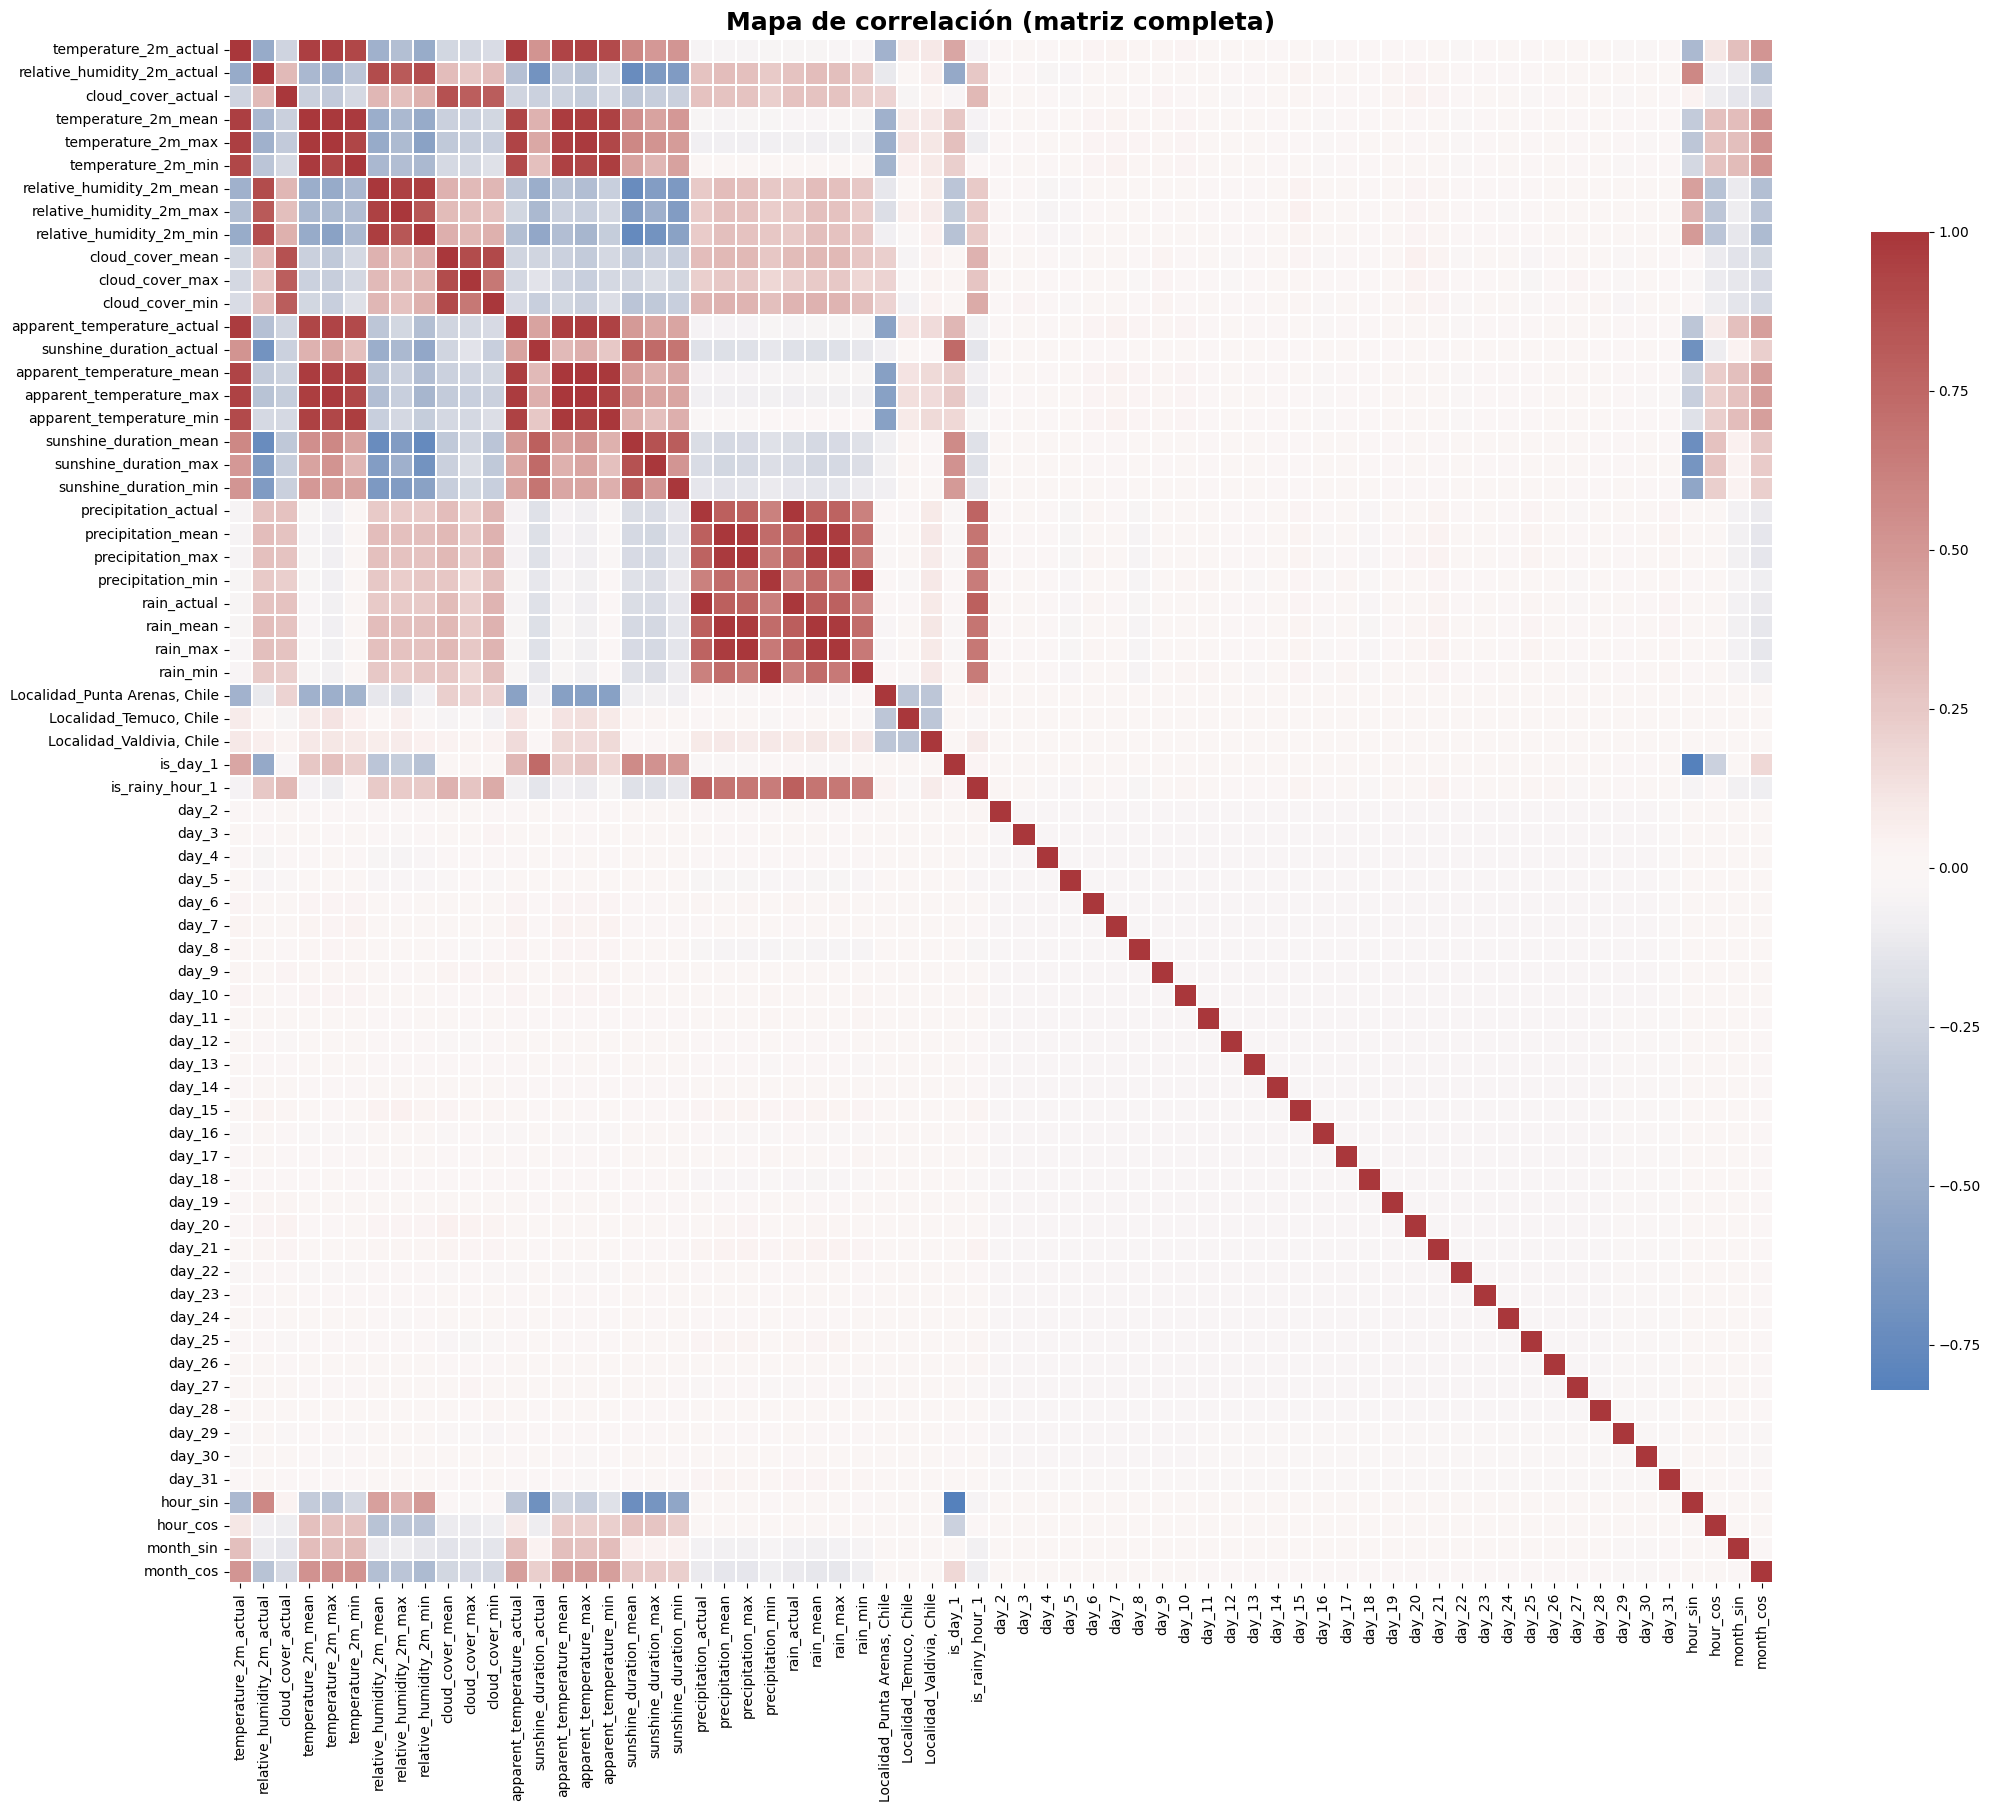

In [ ]:
corr = get_correlation(data_preparada, data_preparada.columns)


In [ ]:
# 1. Calculamos la correlación solo con la variable objetivo
# Usamos 'abs()' (valor absoluto) para ver qué importa más,
# sin importar si es positivo (nubes) o negativo (sol).
correlaciones = data_preparada.corr(numeric_only=True)["is_rainy_hour_1"]

# 2. Ordenamos por importancia (de mayor a menor impacto)
# Así vemos arriba los "motores" y abajo la "basura"
correlaciones_ordenadas = correlaciones.abs().sort_values(ascending=False)

# 3. Imprimimos LA LISTA COMPLETA sin cortes
print(correlaciones_ordenadas.to_string())
print("--- HASTA AQUÍ ---")

is_rainy_hour_1                  1.000000
rain_actual                      0.788992
precipitation_actual             0.767051
rain_mean                        0.683275
precipitation_mean               0.680770
rain_max                         0.666490
precipitation_max                0.659647
rain_min                         0.644906
precipitation_min                0.644238
cloud_cover_min                  0.399840
cloud_cover_mean                 0.363852
cloud_cover_actual               0.327843
cloud_cover_max                  0.272459
relative_humidity_2m_actual      0.250104
relative_humidity_2m_mean        0.243196
relative_humidity_2m_min         0.241568
relative_humidity_2m_max         0.236705
sunshine_duration_mean           0.171803
sunshine_duration_max            0.170954
sunshine_duration_actual         0.139677
sunshine_duration_min            0.130641
apparent_temperature_max         0.108280
temperature_2m_max               0.098541
month_cos                        0

#### Desiciones en la toma de variables

Se eliminaron las variables instantáneas (“actual”) debido a su alta correlación con métricas agregadas y a que pueden introducir data leakage temporal, al incorporar información del mismo instante o muy cercana al evento a predecir. Esto puede generar un desempeño artificialmente inflado durante el entrenamiento y una menor capacidad de generalización. El uso de variables promedio reduce este riesgo y favorece predicciones más estables y realistas.
También se decidió eliminar las variables day_x porque no aportaban en nada al analisis y solo brindaban correlación a los modelos. Por el otro lado, decidimos también volver a analizar la data original y nos dimos cuenta que habían variables que no fueron preparadas en la evaluación anterior, estas variables fueron, 'rain', 'precipitation', 'sunshine_duration','apparent_temperature', todas estas variables van a ser clave para el entrenamiento de los futuros modelos de clasificación para ver si es que pueden predecir correctamente si llueve o no llueve.






#### Identificación de la fuga de información vs cumplir con el umbral solicitado

Al llevar a cabo un análisis de las variables del dataframe junto a su correlación se llegó a la conclusión de que hay una desmesurada fuga de datos al momento de entrenar el modelo incluyendo las variables 'rain_actual' y 'precipitation_actual', esto junto a sus derivadas del min, max y mean. Esto se justifica al momento de completar el entrenamiento del modelo, las métricas son perfectas y no poseen errores, lo cual no puede ser posible en modelos predictivos, ya que el modelo no estaría prediciendo, y estaría memorizando la data al aplicar estas variables con mucha correlación.

No obstante al realizar un análisis lógico y correspondiente a como se debe alimentar un modelo con buenas prácticas, no se llega al umbral solicitado por la rúbrica, esto debido al enorme desbalanceo de las clases derivando en que el F1-SCORE de la clase minoritaria (Llueve), no logre superar el 80% de lo solicitado sin caer en un data-leakage.

In [ ]:
X = data_preparada[
    [

        "temperature_2m_mean",
        "temperature_2m_max",
        "relative_humidity_2m_mean",
        "relative_humidity_2m_max",
        "cloud_cover_mean",
        "cloud_cover_max",
        "Localidad_Punta Arenas, Chile",
        "Localidad_Temuco, Chile",
        "Localidad_Valdivia, Chile",
        "hour_sin", "hour_cos",
        "month_sin", "month_cos",
        'sunshine_duration_mean',
        'sunshine_duration_max',
        'apparent_temperature_mean',
        'apparent_temperature_max',
    ]
]

y = data_preparada["is_rainy_hour_1"]




Aca contamos cuantas veces se tomó en la data que si estaba lloviendo o no para ver como estan distribuidas

In [ ]:
y.value_counts()

,count
is_rainy_hour_1,
0.0,26908
1.0,6100


Al analizar la variable objetivo de nuestros modelos de clasificación, se puede dejar entrever de que el desbalanceo de clases es muy notorio, dando como clase minoritaria cuando la data afirma de que llueve, esto significa de que todos nuestros modelos van a estar decantados en la predicción para la clase mayoritaria, que en este caso seria, no llueve.

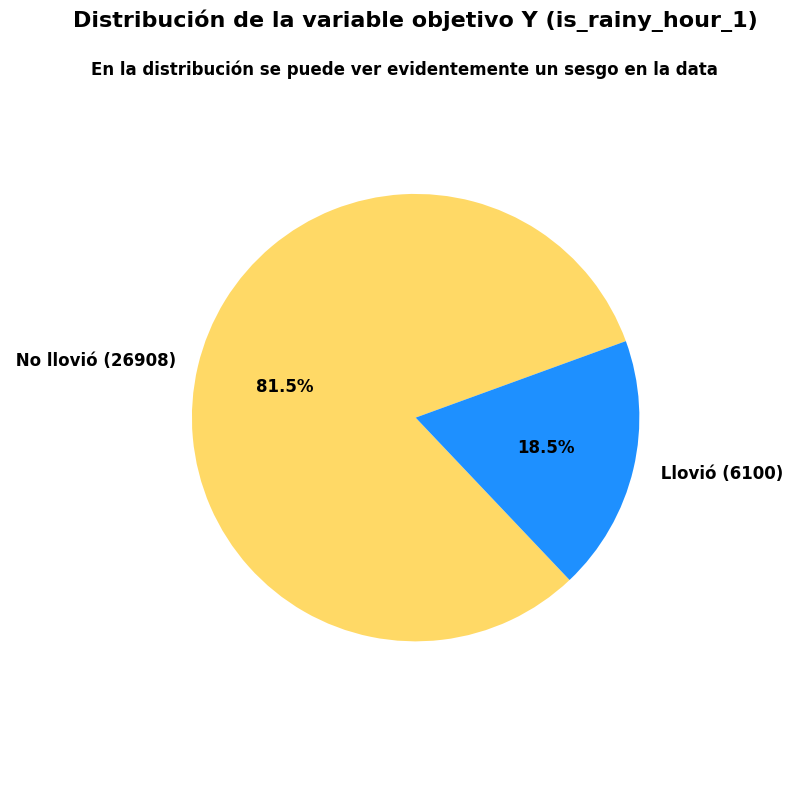

In [ ]:
# Calcular proporciones por clase
clases, counts = np.unique(y, return_counts=True)

# Crear etiquetas personalizadas
labels = [f" {'No llovió' if clases[i]==0 else 'Llovió'} ({counts[i]})"
          for i in range(len(clases))]

# Colores: azul lluvia, amarillo claro no lluvia
colors = ["#FFD966","#1E90FF"]

# Crear gráfico de torta
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=labels, autopct="%1.1f%%", startangle=20,
        colors=colors, textprops={'fontsize': 12, 'weight': 'bold'})
plt.title("Distribución de la variable objetivo Y (is_rainy_hour_1)",
          fontsize=16, fontweight="bold", pad=20)
plt.axis("equal")
plt.tight_layout()
subtitulo = "En la distribución se puede ver evidentemente un sesgo en la data"
plt.figtext(0.51, 0.9, subtitulo, ha='center', fontsize=12, weight='bold', color='black')
plt.show()

### Modelos cumpliendo con umbral pero con data leakage

In [ ]:
X_leakage = data_preparada[
    [
        'rain_actual', # Variables con más data leakage
        'precipitation_actual',
        "temperature_2m_mean",
        "temperature_2m_max",
        "relative_humidity_2m_mean",
        "relative_humidity_2m_max",
        "cloud_cover_mean",
        "cloud_cover_max",
        "Localidad_Punta Arenas, Chile",
        "Localidad_Temuco, Chile",
        "Localidad_Valdivia, Chile",
        "hour_sin", "hour_cos",
        "month_sin", "month_cos",
        'sunshine_duration_mean',
        'sunshine_duration_max',
        'apparent_temperature_mean',
        'apparent_temperature_max',
    ]
]

y_leakage = data_preparada["is_rainy_hour_1"]


##### Logistic Regression - Data Leakage

In [ ]:
X_train_lr_leakage, X_test_lr_leakage, y_train_lr_leakage, y_test_lr_leakage = train_test_split(X_leakage, y_leakage, test_size=0.2, random_state=29,
                                                    stratify=y_leakage)

In [ ]:
# Construir un pipeline solo con Regresión Logística
modelo_lr_leakage = Pipeline([
    ('logreg', LogisticRegression(

        class_weight="balanced",

    ))
])

In [ ]:
# Entrenar el modelo
modelo_lr_leakage.fit(X_train_lr_leakage, y_train_lr_leakage)

Pipeline(steps=[('logreg', LogisticRegression(class_weight='balanced'))])

In [ ]:
# Evaluar el modelo
y_pred_lr_leakage = modelo_lr_leakage.predict(X_test_lr_leakage)

In [ ]:
print("Reporte de Clasificación:")
print(classification_report(y_test_lr_leakage, y_pred_lr_leakage, target_names=['No llueve', 'Llueve']))

Reporte de Clasificación:
              precision    recall  f1-score   support

   No llueve       1.00      1.00      1.00      5382
      Llueve       1.00      1.00      1.00      1220

    accuracy                           1.00      6602
   macro avg       1.00      1.00      1.00      6602
weighted avg       1.00      1.00      1.00      6602



De este modelo con las variables de 'rain' y 'precipitation' no se puede interpretar nada, ya que cae en el concepto de data leakage, haciendo que este modelo no fuese fiable en predecir si es que llueve o no llueve con exactitud.

Decision Tree - Data Leakage

In [ ]:
X_train_dt_leakage, X_test_dt_leakage, y_train_dt_leakage, y_test_dt_leakage = train_test_split(X_leakage, y_leakage, test_size=0.2, random_state=29,
                                                    stratify=y_leakage)

In [ ]:
modelo_dt_leakage = Pipeline(steps=[
    ("classifier", DecisionTreeClassifier(
    ))
    ])

In [ ]:
# Entrenar el modelo
modelo_dt_leakage.fit(X_train_dt_leakage, y_train_dt_leakage)

Pipeline(steps=[('classifier', DecisionTreeClassifier())])

In [ ]:
# Evaluar el modelo
y_pred_dt_leakage = modelo_dt_leakage.predict(X_test_dt_leakage)

In [ ]:
print("Reporte de Clasificación:")
print(classification_report(y_test_dt_leakage, y_pred_dt_leakage, target_names=['No llueve', 'Llueve']))

Reporte de Clasificación:
              precision    recall  f1-score   support

   No llueve       1.00      1.00      1.00      5382
      Llueve       1.00      1.00      1.00      1220

    accuracy                           1.00      6602
   macro avg       1.00      1.00      1.00      6602
weighted avg       1.00      1.00      1.00      6602



La misma interpretación se le puede dar al modelo de decision tree, que incluso aplicando los mejores hiper-parametros del gridsearch, este modelo cae en el concepto de data leakage al incluirle las variables de 'rain' y 'precipitation'.

### 3.2  Modelo de clasificaciòn : Logistic Regression

División de los datos entre Train y Test.

In [ ]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X, y, test_size=0.2, random_state=29,
                                                    stratify=y)

Acá se optó por usar el stratify en la clase minoritaria con la justificación de que este parametro se utiliza para asegurar la proporción de la clase minoritaria y la mayoritaria se mantenga constante al dividir los grupos en train y test. Esto es importante al conocer el desbalanceo de clases, ya que permite evaluar el modelo de forma mas precisa y considerando el sesgo en la data.

Creación del modelo LR

In [ ]:
# Construir un pipeline solo con Regresión Logística
modelo_lr = Pipeline([
    ('logreg', LogisticRegression(

        class_weight="balanced",

    ))
])

El class_weight="balanced" es un hiper-parametro, esto ayuda a que el modelo no favorezca a la clase mayoritaria (no llueve) y mejore el aprendizaje de la clase minoritaria (llueve).

Entrenamiento del modelo LR

In [ ]:
# Entrenar el modelo
modelo_lr.fit(X_train_lr, y_train_lr)

Pipeline(steps=[('logreg', LogisticRegression(class_weight='balanced'))])

Evaluación del modelo Logistic Regression

In [ ]:
# Evaluar el modelo
y_pred_lr = modelo_lr.predict(X_test_lr)

####Métricas del modelo Logistic Regression

In [ ]:
print("Reporte de Clasificación:")
print(classification_report(y_test_lr, y_pred_lr, target_names=['No llueve', 'Llueve']))

Reporte de Clasificación:
              precision    recall  f1-score   support

   No llueve       0.95      0.76      0.84      5382
      Llueve       0.44      0.82      0.57      1220

    accuracy                           0.77      6602
   macro avg       0.69      0.79      0.71      6602
weighted avg       0.85      0.77      0.79      6602



Interpretaciones del Reporte de Clasificación


No llueve

| Métrica              |                                                                                            | Interpretación |
| -------------------- | ------------------------------------------------------------------------------------------ | -------------- |
| **Precision = 0.95** | De todas las veces que el modelo predijo “No llueve”, acertó el **95%** de las ocasiones.  |                |
| **Recall = 0.76**    | El modelo detectó correctamente el **76%** de los días en los que realmente **no llovió**. |                |
| **F1-score = 0.84**  | Excelente equilibrio entre precision y recall para esta clase.                             |                |

Llueve

| Métrica              |                                                                                            | Interpretación |
| -------------------- | ------------------------------------------------------------------------------------------ | -------------- |
| **Precision = 0.44** | De las predicciones “Llueve”, solo el **44%** correspondieron realmente a días con lluvia. |                |
| **Recall = 0.82**    | El modelo solo logra detectar el **82%** de los días en los que **sí llovió**.             |                |
| **F1-score = 0.57**  | Desempeño más débil en esta clase, con dificultad para identificar eventos de lluvia.      |                |


#### Matriz de confusión Logistic Regression

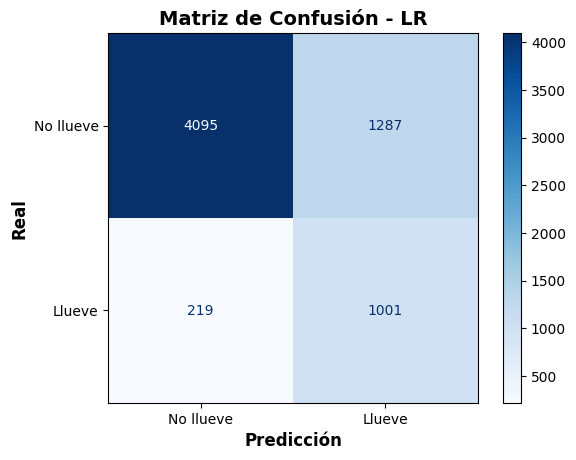

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test_lr, y_pred_lr,
                                        display_labels=["No llueve", "Llueve"],
                                        cmap="Blues")
plt.title("Matriz de Confusión - LR", fontsize=14, fontweight="bold")
plt.xlabel("Predicción", fontsize=12, fontweight="bold")
plt.ylabel("Real", fontsize=12, fontweight="bold")
plt.show()

Interpretación:

```
[4095 1287]
[ 219 1001]
```


Verdaderos Negativos (cm[0,0]): 4095
→ Días en los que NO llovió y el modelo los clasificó correctamente como No llueve.

Falsos Positivos (cm[0,1]): 1287
→ Días en los que NO llovió, pero el modelo predijo que sí llovía.

Falsos Negativos (cm[1,0]): 219
→ Días en los que sí llovió, pero el modelo predijo que no llovía.

Verdaderos Positivos (cm[1,1]): 1001
→ Días en los que sí llovió y el modelo los clasificó correctamente como Llueve.

### 3.3 Modelo de clasificaciòn : Descicion Tree

In [ ]:
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X, y, test_size=0.2, random_state=29,
                                                    stratify=y)

Creación del modelo Descision Tree

In [ ]:
modelo_dt = Pipeline(steps=[
    ("classifier", DecisionTreeClassifier(
    ))
    ])


#LOS 3 HIPERPARAMETROS

param_grid = {
    # Profundidad y complejidad del árbol
    'classifier__max_depth': [5, 10, 15, 20, None],


    # Criterio de división
    'classifier__criterion': ['gini', 'entropy'],

    # Pesos de clase (útil si tienes desbalance)
    'classifier__class_weight': [None, 'balanced'],
}

grid = GridSearchCV(
    estimator=modelo_dt,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_dt, y_train_dt)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=29, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__class_weight': [None, 'balanced'],
                         'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [5, 10, 15, 20, None]},
             scoring='f1')

Estos hiperparámetros definen cómo crece y decide un árbol de decisión: max_depth controla la complejidad del modelo (más profundidad = más riesgo de sobreajuste), criterion indica cómo el árbol elige los cortes entre gini o entropy, los cuales ven si la data es igual o están todas mezcladas, y class_weight ajusta la importancia de cada clase, siendo clave en datos desbalanceados para mejorar el rendimiento de la clase minoritaria.

In [ ]:
print(f"Mejor puntaje (F1): {grid.best_score_:.4f}")
print(f"Mejores hiperparámetros: {grid.best_params_}")

Mejor puntaje (F1): 0.6089
Mejores hiperparámetros: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 20}


Entrenamiento del modelo Descision Tree

In [ ]:
#linea importante
mejor_modelo_dt = grid.best_estimator_


Evaluación del modelo Descision Tree

In [ ]:
# Ahora entrena el mejor modelo
mejor_modelo_dt.fit(X_train_dt, y_train_dt)

Pipeline(steps=[('classifier',
                 DecisionTreeClassifier(class_weight='balanced',
                                        criterion='entropy', max_depth=20))])

####Métricas del modelo Descision Tree

In [ ]:
# Realiza las predicciones con el mejor modelo, usando la data de prueba
y_pred_dt = mejor_modelo_dt.predict(X_test_dt)
print(classification_report(y_test_dt, y_pred_dt, target_names=["No llueve","Llueve"]
))

              precision    recall  f1-score   support

   No llueve       0.91      0.89      0.90      5382
      Llueve       0.56      0.59      0.57      1220

    accuracy                           0.84      6602
   macro avg       0.73      0.74      0.74      6602
weighted avg       0.84      0.84      0.84      6602



Interpretaciones del Reporte de Clasificación

No llueve

| Métrica              |                                                                                            | Interpretación |
| -------------------- | ------------------------------------------------------------------------------------------ | -------------- |
| **Precision = 0.91** | De todas las veces que el modelo predijo “No llueve”, acertó el **91%** de las ocasiones.  |                |
| **Recall = 0.89**    | El modelo detectó correctamente el **89%** de los días en los que realmente **no llovió**. |                |
| **F1-score = 0.90**  | Muy buen equilibrio entre precision y recall para esta clase.                              |                |

Llueve

| Métrica              |                                                                                            | Interpretación |
| -------------------- | ------------------------------------------------------------------------------------------ | -------------- |
| **Precision = 0.56** | De las predicciones “Llueve”, solo el **56%** correspondieron realmente a días con lluvia. |                |
| **Recall = 0.59**    | El modelo solo logra detectar el **59%** de los días en los que **sí llovió**.             |                |
| **F1-score = 0.57**  | Desempeño medio en esta clase, con alta dificultad para identificar eventos de lluvia.      |                |


#### Matriz de confusión Descicion Tree

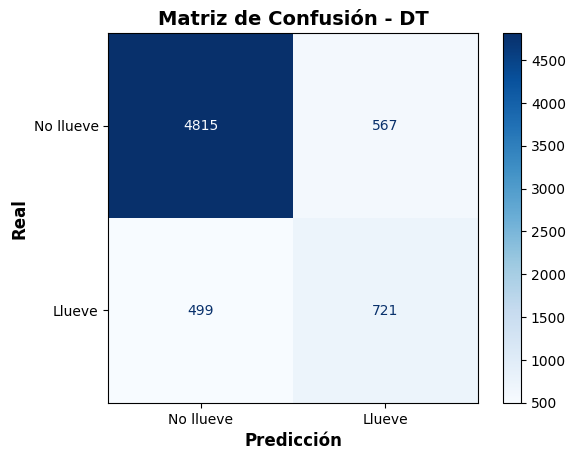

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test_dt, y_pred_dt,
                                        display_labels=["No llueve", "Llueve"],
                                        cmap="Blues")
plt.title("Matriz de Confusión - DT", fontsize=14, fontweight="bold")
plt.xlabel("Predicción", fontsize=12, fontweight="bold")
plt.ylabel("Real", fontsize=12, fontweight="bold")
plt.show()

```
[4815 567]
[ 499 721]
```


Verdaderos Negativos (cm[0,0]): 4815
→ Días en los que NO llovió y el modelo los clasificó correctamente como No llueve.

Falsos Positivos (cm[0,1]): 567
→ Días en los que NO llovió, pero el modelo predijo que sí llovía.

Falsos Negativos (cm[1,0]): 499
→ Días en los que sí llovió, pero el modelo predijo que no llovía.

Verdaderos Positivos (cm[1,1]): 721
→ Días en los que sí llovió y el modelo los clasificó correctamente como Llueve.

### 3.4 Modelo de clasificaciòn : SVM

#### Exploración y Justificación del Kernel

In [ ]:
X_svm = data_preparada[
    [
        'relative_humidity_2m_actual',
        'cloud_cover_actual'

    ]
]

y_svm = data_preparada['is_rainy_hour_1']


y_svm.value_counts()


,count
is_rainy_hour_1,
0.0,26908
1.0,6100


Aca se uso el Silhouette para ver la distribución de las variables.

In [ ]:
silhouette_avg = silhouette_score(X_svm, y_svm)
print(f"Índice de Silhouette: {silhouette_avg : .4f}")

Índice de Silhouette:  0.0032


Cuando el indice del Silhouette es mas cercano a cero eso significa que los puntos estan mas mezclados entre ellos y no hay separación evidente para trazar una linea para usar el kernel lineal.

In [ ]:
def plot_data(X_svm : np.array, y_svm : np.array, labels : list, title="Distribución de los datos") -> None:
  """
  Genera gráfico para ver la distribución de los datos

  Parámetros:
  ----------
  - X_svm: Matriz de características
  - y_svm: Etiquetas de clase
  - labels: Etiquetas de clase (lista de strings)
  - title: Título del gráfico

  Retorna:
  --------
  - None
  """
  plt.figure(figsize=(8, 6))
  for label in np.unique(y_svm):
    plt.scatter(X_svm[y_svm == label, 0], X_svm[y_svm == label, 1],
                label=f"{labels[int(label)]}", alpha=0.8)
  plt.title(title, fontsize=14, fontweight="bold")
  plt.xlabel("Temperatura y Cloud Cover", fontsize=12, fontweight="bold")
  plt.ylabel("Lluvia", fontsize=12, fontweight="bold")
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()

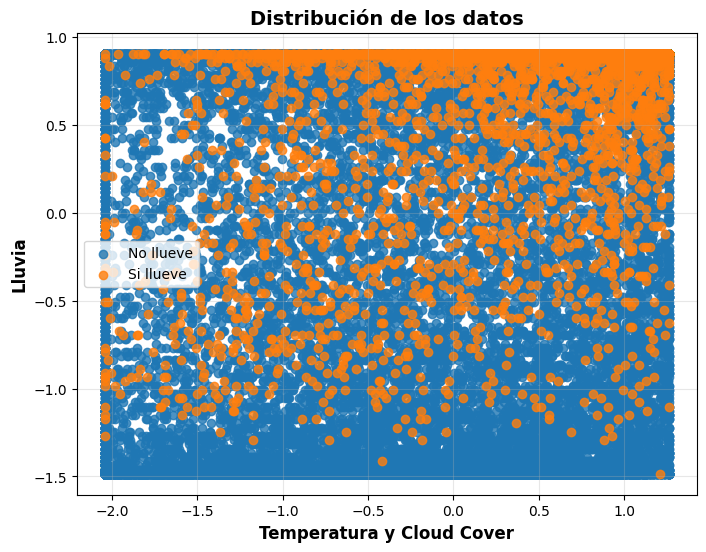

In [ ]:
plot_data(X_svm.values, y_svm.values, ['No llueve', 'Si llueve'])

Aqui en este gráfico se puede dejar ver con más claridad la interpretación del silouethe, dando como conclusión de que es correcta la decision de optar por un kernel no lineal dentro del modelo predictivo SVM.

División de los datos entre train y test

In [ ]:
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_svm, y_svm, test_size=0.2, random_state=29,
                                                    stratify=y_svm)

Creación del modelo SVM

In [ ]:
modelo_svm = Pipeline([
    ('classifier', SVC(kernel="rbf", class_weight='balanced',probability=True))
])

Entrenamiento del modelo SVM

In [ ]:
modelo_svm.fit(X_train_svm, y_train_svm)

Pipeline(steps=[('classifier', SVC(class_weight='balanced', probability=True))])

Evaluación del modelo SVM

In [ ]:
y_pred_svm = modelo_svm.predict(X_test_svm)

####Métricas del modelo SVM

In [ ]:
print(classification_report(
    y_test_svm,
    modelo_svm.predict(X_test_svm), target_names=["No llueve","Llueve"]
))

              precision    recall  f1-score   support

   No llueve       0.93      0.66      0.77      5382
      Llueve       0.34      0.80      0.48      1220

    accuracy                           0.68      6602
   macro avg       0.64      0.73      0.63      6602
weighted avg       0.83      0.68      0.72      6602



Interpretaciones del Reporte de Clasificación

No llueve

| Métrica              |                                                                                             | Interpretación |
| -------------------- | ------------------------------------------------------------------------------------------- | -------------- |
| **Precision = 0.93** | De todas las veces que el modelo predijo “No llueve”, acertó el **93%** de las ocasiones.   |                |
| **Recall = 0.66**    | El modelo detectó correctamente el **66%** de las horas en las que realmente **no llovió**. |                |
| **F1-score = 0.77**  | Buen equilibrio entre precision y recall, aunque con pérdidas en la detección total.        |                |

Llueve

| Métrica              |                                                                                             | Interpretación |
| -------------------- | ------------------------------------------------------------------------------------------- | -------------- |
| **Precision = 0.34** | De las predicciones “Llueve”, solo el **34%** correspondieron realmente a horas con lluvia. |                |
| **Recall = 0.80**    | El modelo logra detectar el **80%** de las horas en las que **sí llovió**.                  |                |
| **F1-score = 0.48**  | Desempeño bajo en esta clase, con alta tasa de falsos positivos.                            |                |


#### Matriz de confusión SVM

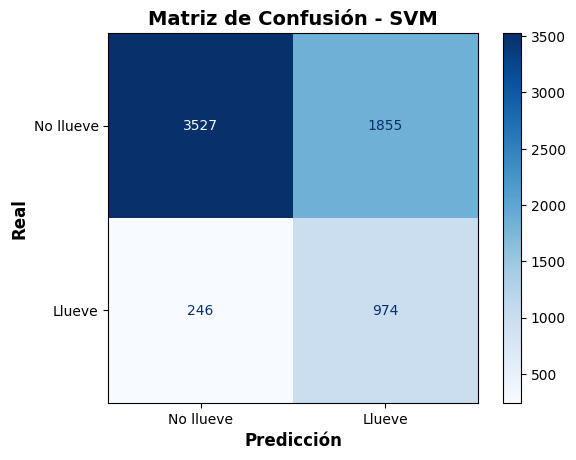

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test_svm, y_pred_svm,
                                        display_labels=["No llueve", "Llueve"],
                                        cmap="Blues")
plt.title("Matriz de Confusión - SVM", fontsize=14, fontweight="bold")
plt.xlabel("Predicción", fontsize=12, fontweight="bold")
plt.ylabel("Real", fontsize=12, fontweight="bold")
plt.show()

```
[3527 1855]
[ 246 974]
```


Verdaderos Negativos (cm[0,0]): 3527
→ Días en los que NO llovió y el modelo los clasificó correctamente como No llueve.

Falsos Positivos (cm[0,1]): 1855
→ Días en los que NO llovió, pero el modelo predijo que sí llovía.

Falsos Negativos (cm[1,0]): 246
→ Días en los que sí llovió, pero el modelo predijo que no llovía.

Verdaderos Positivos (cm[1,1]): 974
→ Días en los que sí llovió y el modelo los clasificó correctamente como Llueve.

# 4.0 Segmentación: Modelo Kmeans (HORA Y MES CÍCLICO)

Para definir la segmentación de nuestros datos, analizamos la inercia, métrica que buscamos que sea lo más baja posible para asegurar que los datos dentro de cada clúster (grupo) sean similares entre sí. Al observar el comportamiento del modelo, confirmamos que mientras más clusters hay, menor es la inercia; sin embargo, esta mejora tiene un límite práctico. Detectamos que llega un punto donde la ganancia en reducción de inercia ya no es significativa respecto a la complejidad agregada (punto de quiebre). Basándonos en el análisis del Método del Codo

In [19]:
#definir variables
x_ciclico = data_preparada [['hour_cos', 'hour_sin', 'temperature_2m_actual', 'month_cos', 'month_sin']]

In [20]:
# Experimentar con valor de k
inertias = []
silhouettes = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=29)
    km.fit(x_ciclico)
    # Almacena inercias y el valor de una métrica
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(x_ciclico, km.labels_))

In [21]:
data_preparada.shape

(33008, 67)

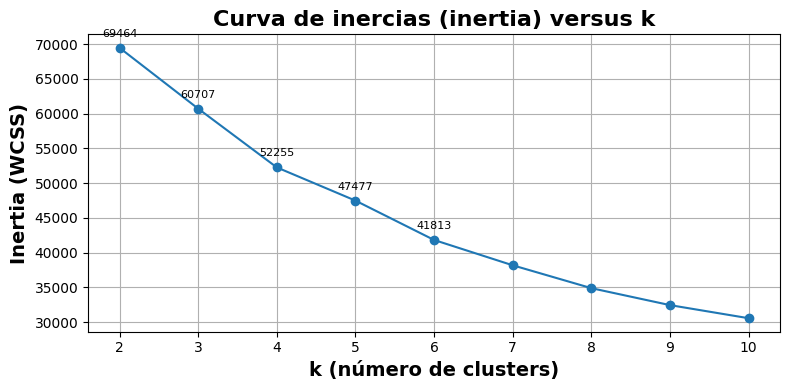

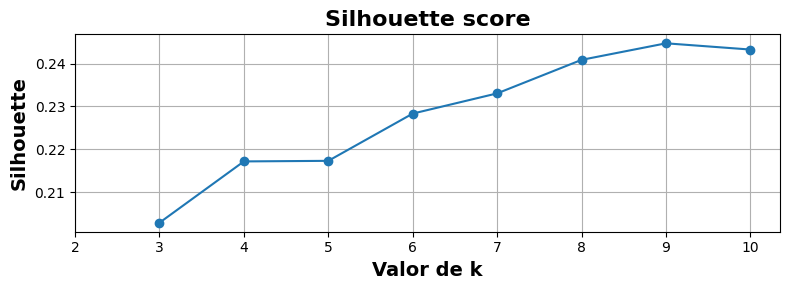

In [22]:
# Graficar inertias (Elbow plot)
range_k = range(2, 11)
plt.figure(figsize=(8,4))
plt.plot(list(range_k), inertias, marker='o')
plt.title("Curva de inercias (inertia) versus k", fontsize=16, fontweight="bold")
plt.xlabel("k (número de clusters)", fontsize=14, fontweight="bold")
plt.ylabel("Inertia (WCSS)", fontsize=14, fontweight="bold")
plt.xticks(list(range_k))

for k_val, val in zip(list(range_k), inertias):
    if k_val <= 6:
        plt.annotate(f"{val:.0f}", (k_val, val), textcoords="offset points", xytext=(0,8), ha='center', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

# Grafica el índice de silhoutte
plt.figure(figsize=(8,3))
plt.plot(list(range_k)[1:], silhouettes[1:], marker='o')
plt.title("Silhouette score", fontsize=16, fontweight="bold")
plt.xlabel("Valor de k", fontsize=14, fontweight="bold")
plt.ylabel("Silhouette", fontsize=14, fontweight="bold")
plt.xticks(list(range_k))
plt.grid(True)
plt.tight_layout()
plt.show()

El gráfico muestra un punto de quiebre (codo) en k=6. Antes de este valor, la inercia cae drásticamente mejorando la cohesión; después, la curva se estabiliza y la ganancia es marginal. Seleccionamos 6 clústeres porque ofrece el equilibrio óptimo entre precisión y simplicidad, evitando el sobreajuste.

In [23]:
# Obtiene el mejor valor de k
kl = KneeLocator(range_k, inertias, curve="convex", direction="decreasing")
print(f"El codo está en k = {kl.elbow}")
print(f"Valor de la inercia = {kl.all_elbows_y[0]: .2f}")

El codo está en k = 6
Valor de la inercia =  41813.10


In [24]:
# Elegir k óptimo para continuar
kmeans = KMeans(n_clusters=kl.elbow, random_state=29)
data_preparada['cluster'] = kmeans.fit_predict(x_ciclico)

# Interpretación
data_preparada.head()

,temperature_2m_actual,relative_humidity_2m_actual,cloud_cover_actual,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,relative_humidity_2m_max,relative_humidity_2m_min,cloud_cover_mean,...,day_27,day_28,day_29,day_30,day_31,hour_sin,hour_cos,month_sin,month_cos,cluster
0,0.589208,-0.561102,-1.484396,0.804869,0.642428,0.944406,-0.842016,-1.041545,-0.635727,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.965926,-0.258819,0.5,0.866025,1
1,0.484369,-0.056782,-1.484396,0.710283,0.602846,0.827929,-0.752328,-0.530286,-0.635727,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.866025,-0.500000,0.5,0.866025,1
2,0.379530,0.576254,-1.484396,0.602798,0.503892,0.711452,-0.421597,0.239273,-0.635727,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.707107,-0.707107,0.5,0.866025,1
3,0.306143,0.849110,-1.484396,0.501762,0.404937,0.629918,-0.012989,0.570974,-0.453677,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.500000,-0.866025,0.5,0.866025,1
4,0.578724,0.393792,-1.484396,0.478116,0.305983,0.629918,0.257189,0.570974,-0.160589,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.258819,-0.965926,0.5,0.866025,1


###Ejecución del algoritmo kmeans

In [25]:
pipeline_km = Pipeline([

    ("kmeans", KMeans(n_clusters=kl.elbow, random_state=29))
])

In [26]:
pipeline_km.fit(x_ciclico)
clusters = pipeline_km.predict(x_ciclico)
data_preparada["cluster"] = clusters

In [27]:
# Obtener el modelo entrenado
kmeans = pipeline_km.named_steps["kmeans"]

# Obtener los centroides en el espacio transformado
centroides_transformados = kmeans.cluster_centers_

print(centroides_transformados)

[[-7.13784062e-01  1.69455088e-01 -1.06240383e+00 -7.45235405e-01
  -1.07908358e-01]
 [-1.46780109e-01  4.85021594e-01  2.22446984e-01  2.61768717e-01
   7.67659068e-01]
 [ 3.18987803e-02  6.17706130e-01 -4.36915646e-01  3.84068321e-01
  -7.62987398e-01]
 [ 1.45966070e-01 -6.50671244e-01  1.47970141e+00  4.61067977e-01
   5.01959554e-01]
 [-1.31529918e-02 -7.43820365e-01  3.31817211e-01 -1.25842407e-01
  -6.16177671e-01]
 [ 7.42921469e-01  1.24043697e-01 -7.75378307e-01 -7.65091912e-01
   2.85186490e-04]]


In [28]:
def obtener_centroides_originales_simple(kmeans_model, x_ciclico, data):
    """
    Convierte centroides de coordenadas cíclicas a escala original.

    Parámetros:
        kmeans_model: modelo KMeans entrenado
        x_ciclico: dataframe con ['hour_cos', 'hour_sin', 'temperature_2m']
        data: DataFrame original con 'temperature_2m' SIN procesar

    Retorna: DataFrame con centroides en escala original
    """
    # Crear y ajustar el scaler con los datos originales
    scaler_temp = StandardScaler()
    scaler_temp.fit(data[['temperature_2m']])

    centroides = kmeans_model.cluster_centers_

    resultados = []
    for i, centroide in enumerate(centroides):
        hour_cos, hour_sin,month_cos, month_sin,  temp_escalada = centroide

        # Convertir de coordenadas cíclicas a hora original
        hora_original = np.arctan2(hour_sin, hour_cos) * 24 / (2 * np.pi)
        if hora_original < 0:
            hora_original += 24

        # Convertir mes
        mes_radianes = np.arctan2(month_sin, month_cos)
        mes_original = (mes_radianes * 12 / (2 * np.pi)) + 1
        if mes_original < 1:
            mes_original += 12

        mes_num = int(round(mes_original))
        if mes_num < 1:
            mes_num = 1
        elif mes_num > 12:
            mes_num = 12


        # INVERTIR la transformación de temperatura
        temp_original = scaler_temp.inverse_transform([[temp_escalada]])[0][0]

        resultados.append({
            'cluster': i,
            'hora_promedio': hora_original,
            'mes_num': mes_num,
            'temperatura_promedio_°C': temp_original,  # ← Ahora en grados reales
        })

    return pd.DataFrame(resultados)

In [29]:
# Obtiene los centroides originales
df_centroides = obtener_centroides_originales_simple(
    kmeans,
    x_ciclico,
    data
)

df_centroides

,cluster,hora_promedio,mes_num,temperatura_promedio_°C
0,0,11.109666,8,10.081518
1,1,7.122478,3,14.646096
2,2,5.802922,6,6.666408
3,3,18.842928,2,13.260930
4,4,17.932463,12,7.431768
5,5,0.631939,8,10.645561


La segmentación funciona porque logró separar perfectamente los eventos extremos (mucho frío o mucho calor) de los días normales.

Por ejemplo (aproximados):
- Clúster 1 (0) : pudo identificar correctamente el patrón de las mañanas de agosto, teniendo un promedio de 10° Celcius, agrupandolos.
- Clúster 3 (2) : pudo identificar las heladas de las mañanas de Junio, con una temperatura promedio de 6° Celcius

Algunos clusters se ven afectados debido a la diversidad de los datos  por  localidades implementadas, los patrones generales por hora y mes si se logran identificar efectivamente

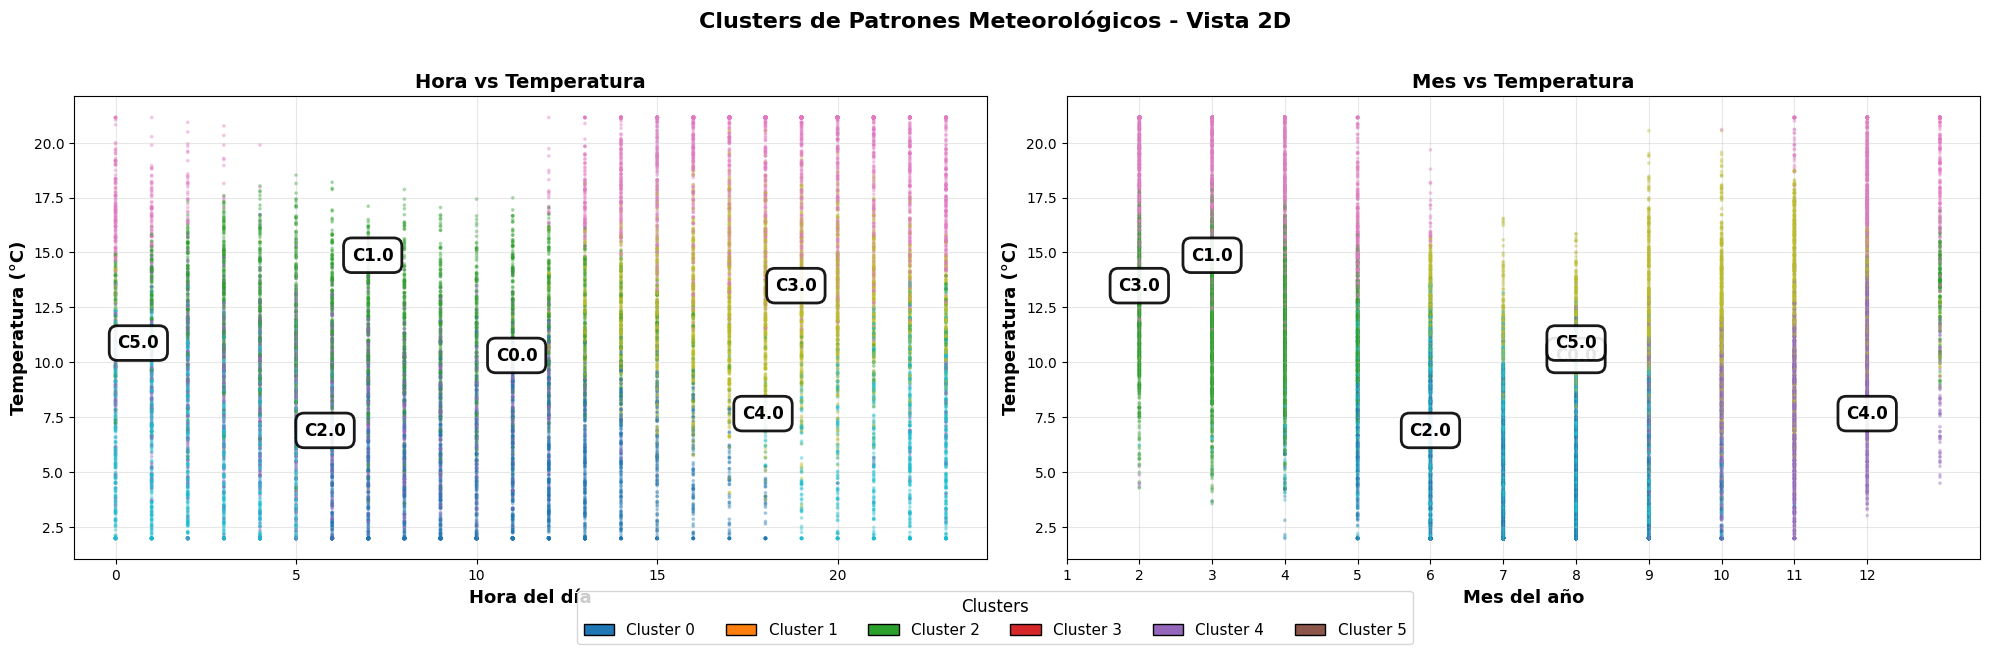

In [33]:
def graficar_clusters_2d_limpio(data_preparada: pd.DataFrame,
                                 df_centroides: pd.DataFrame,
                                 cluster_col="cluster") -> None:

    # Preparar datos
    if 'hour_original' not in data_preparada.columns:
        data_preparada['hour_original'] = np.arctan2(
            data_preparada['hour_sin'],
            data_preparada['hour_cos']
        ) * 24 / (2 * np.pi)
        data_preparada['hour_original'] = data_preparada['hour_original'].apply(
            lambda x: x + 24 if x < 0 else x
        )

    if 'month_original' not in data_preparada.columns:
        data_preparada['month_original'] = np.arctan2(
            data_preparada['month_sin'],
            data_preparada['month_cos']
        ) * 12 / (2 * np.pi) + 1
        data_preparada['month_original'] = data_preparada['month_original'].apply(
            lambda x: x + 12 if x < 1 else x
        )

    # Crear scaler para temperatura
    scaler_temp = StandardScaler()
    col_temp = 'temperature_2m' if 'temperature_2m' in data.columns else 'temperature_2m_actual'
    scaler_temp.fit(data[[col_temp]])

    temp_escalada = data_preparada['temperature_2m_actual'].values.reshape(-1, 1)
    data_preparada['temp_original'] = scaler_temp.inverse_transform(temp_escalada)

    # Submuestreo
    sample_size = min(15000, len(data_preparada))
    data_sample = data_preparada.sample(n=sample_size, random_state=29)

    # Crear figura
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # GRÁFICO 1: Hora vs Temperatura
    ax1 = axes[0]
    scatter1 = ax1.scatter(
        data_sample['hour_original'],
        data_sample['temp_original'],
        c=data_sample[cluster_col],
        cmap='tab10',
        s=3,
        alpha=0.3
    )

    ax1.scatter(
        df_centroides['hora_promedio'],
        df_centroides['temperatura_promedio_°C'],
        s=600,
        c=df_centroides['cluster'],
        cmap='tab10',
        marker='none',
        linewidth=3,
        zorder=10
    )

    for _, row in df_centroides.iterrows():
        ax1.annotate(f"C{row['cluster']}",
                     xy=(row['hora_promedio'], row['temperatura_promedio_°C']),
                     fontsize=12, fontweight='bold', ha='center',
                     bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                              alpha=0.9, edgecolor='black', linewidth=2))

    ax1.set_xlabel('Hora del día', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Temperatura (°C)', fontsize=13, fontweight='bold')
    ax1.set_title('Hora vs Temperatura', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # GRÁFICO 2: Mes vs Temperatura
    ax2 = axes[1]
    scatter2 = ax2.scatter(
        data_sample['month_original'],
        data_sample['temp_original'],
        c=data_sample[cluster_col],
        cmap='tab10',
        s=3,
        alpha=0.3
    )

    ax2.scatter(
        df_centroides['mes_num'],
        df_centroides['temperatura_promedio_°C'],
        s=600,
        c=df_centroides['cluster'],
        cmap='tab10',
        marker='none',
        linewidth=3,
        zorder=10
    )

    for _, row in df_centroides.iterrows():
        ax2.annotate(f"C{row['cluster']}",
                     xy=(row['mes_num'], row['temperatura_promedio_°C']),
                     fontsize=12, fontweight='bold', ha='center',
                     bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                              alpha=0.9, edgecolor='black', linewidth=2))

    ax2.set_xlabel('Mes del año', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Temperatura (°C)', fontsize=13, fontweight='bold')
    ax2.set_title('Mes vs Temperatura', fontsize=14, fontweight='bold')
    ax2.set_xticks(range(1, 13))
    ax2.grid(True, alpha=0.3)

    # AGREGAR LEYENDA
    # Obtener clusters únicos ordenados
    clusters_unicos = sorted(data_sample[cluster_col].unique())

    # Crear elementos personalizados para la leyenda
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=plt.cm.tab10(i/10),
                             edgecolor='black',
                             label=f'Cluster {i}')
                      for i in clusters_unicos]

    # Agregar la leyenda en la figura completa (centrada)
    fig.legend(handles=legend_elements,
              loc='lower center',
              ncol=len(clusters_unicos),
              bbox_to_anchor=(0.5, -0.05),
              fontsize=11,
              frameon=True,
              title='Clusters',
              title_fontsize=12)

    plt.suptitle('Clusters de Patrones Meteorológicos - Vista 2D',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Usar
graficar_clusters_2d_limpio(data_preparada, df_centroides, cluster_col='cluster')

El gráfico confirma visualmente que el modelo es exitoso

Cada cluster indicado  en las gráfica es donde hay un centroide

Interpretaciones Mes vs Temperatura:

-  (Clúster 4) (C3): Separa claramente el Calor Extremo (Verano).

-  (Clúster 3) (C2): Separa claramente el Frío Extremo (Invierno).

-  (Clúster 4 y 1) (C5 Y C0) Centro: Agrupa todo el resto del año como 'clima estable'.

Conclusión: El modelo sirve porque distingue automáticamente las horas o meses peligrosos (extremos) de los días normales, cumple con su proposito de efectivamente segmentar la data y ayudar a la identificación de patrones.

# 5.0 Análisis de sobreentrenamiento

Con el fin de evaluar el desempeño y la capacidad de generalización de los modelos desarrollados, se analizarán las métricas de entrenamiento y prueba para los tres algoritmos seleccionados. A partir de estos resultados, se aplicarán los criterios establecidos para identificar posibles comportamientos de sobreentrenamiento u otros patrones.


| Situación                          | Interpretación |
|-----------------------------------|----------------|
| Train muy alto, Test mucho más bajo | Overfitting     |
| Train y Test similares y buenos     | Modelo correcto |
| Train y Test similares pero bajos    | Underfitting    |


Este análisis permitirá determinar la calidad del aprendizaje en cada modelo y su capacidad para generalizar a datos nuevos.

###Modelo 1: Regresión Logistica

Métricas

In [ ]:
# Predicciones en test
y_pred_lr = modelo_lr.predict(X_test_lr)
y_proba_lr = modelo_lr.predict_proba(X_test_lr)[:, 1]

# Cálculo de métricas
test_acc_lr = accuracy_score(y_test_lr, y_pred_lr)
test_precision_lr = precision_score(y_test_lr, y_pred_lr)
test_f1_lr = f1_score(y_test_lr, y_pred_lr)

print("=== Métricas en Test ===")
print(f"{'Accuracy en test':<35} : {test_acc_lr:.2f}")
print(f"{'Precisión en test':<35} : {test_precision_lr:.2f}")
print(f"{'F1 score en test':<35} : {test_f1_lr:.2f}")


=== Métricas en Test ===
Accuracy en test                    : 0.77
Precisión en test                   : 0.44
F1 score en test                    : 0.57


In [ ]:
# Predicciones en train
train_pred_lr = modelo_lr.predict(X_train_lr)
train_proba_lr = modelo_lr.predict_proba(X_train_lr)[:, 1]

# Cálculo de métricas
train_acc_lr = accuracy_score(y_train_lr, train_pred_lr)
train_precision_lr = precision_score(y_train_lr, train_pred_lr)
train_f1_lr = f1_score(y_train_lr, train_pred_lr)

print("=== Métricas en Entrenamiento ===")
print(f"{'Accuracy en entrenamiento':<35} : {train_acc_lr:.2f}")
print(f"{'Precisión en entrenamiento':<35} : {train_precision_lr:.2f}")
print(f"{'F1 score en entrenamiento':<35} : {train_f1_lr:.2f}")

=== Métricas en Entrenamiento ===
Accuracy en entrenamiento           : 0.77
Precisión en entrenamiento          : 0.44
F1 score en entrenamiento           : 0.57


In [ ]:
resumen_lr = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_acc_lr, test_acc_lr],
    "Precision": [train_precision_lr, test_precision_lr],
    "F1 score": [train_f1_lr, test_f1_lr]
}).round(4)

display(resumen_lr)

,Dataset,Accuracy,Precision,F1 score
0,Train,0.7695,0.4351,0.5707
1,Test,0.7719,0.4375,0.5707


Gráfico

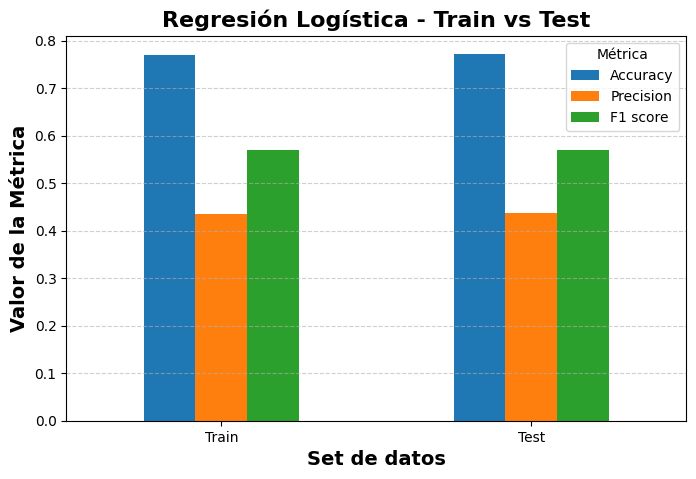

In [ ]:
plt.figure(figsize=(8,5))

ax = resumen_lr.set_index("Dataset").plot(kind="bar", ax=plt.gca())
plt.title("Regresión Logística - Train vs Test", fontsize=16, fontweight="bold")
plt.ylabel("Valor de la Métrica", fontsize=14, fontweight="bold")
plt.xlabel("Set de datos", fontsize=14, fontweight="bold")
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


Interpretaciones

El modelo presenta valores de accuracy similares en entrenamiento (0.76) y prueba (0.77), lo que indica que no existe sobreajuste y que el modelo generaliza de forma consistente. Sin embargo, la precision cercana a 0.43 muestra que una parte importante de las predicciones positivas (lluvia) son falsas alarmas, mientras que el F1-score alrededor de 0.57 refleja un desempeño moderado en la clase minoritaria, evidenciando que el modelo logra detectar lluvia, pero aún con dificultades para equilibrar correctamente precisión y recall.

###Modelo 2: Descision Tree

Métricas

In [ ]:
# ===== MÉTRICAS EN TEST =====
# Predicciones en test
y_pred_dt = mejor_modelo_dt.predict(X_test_dt)
y_proba_dt = mejor_modelo_dt.predict_proba(X_test_dt)[:, 1]

# Cálculo de métricas
test_acc_dt = accuracy_score(y_test_dt, y_pred_dt)
test_precision_dt = precision_score(y_test_dt, y_pred_dt)
test_f1_dt = f1_score(y_test_dt, y_pred_dt)

print("=== Métricas en Test ===")
print(f"{'Accuracy en test':<35} : {test_acc_dt:.2f}")
print(f"{'Precisión en test':<35} : {test_precision_dt:.2f}")
print(f"{'F1 score en test':<35} : {test_f1_dt:.2f}")

=== Métricas en Test ===
Accuracy en test                    : 0.84
Precisión en test                   : 0.56
F1 score en test                    : 0.57


In [ ]:
# ===== MÉTRICAS EN TRAIN =====
# Predicciones en train
train_pred_dt = mejor_modelo_dt.predict(X_train_dt)
train_proba_dt = mejor_modelo_dt.predict_proba(X_train_dt)[:, 1]

# Cálculo de métricas
train_acc_dt = accuracy_score(y_train_dt, train_pred_dt)
train_precision_dt = precision_score(y_train_dt, train_pred_dt)
train_f1_dt = f1_score(y_train_dt, train_pred_dt)

print("=== Métricas en Entrenamiento ===")
print(f"{'Accuracy en entrenamiento':<35} : {train_acc_dt:.2f}")
print(f"{'Precisión en entrenamiento':<35} : {train_precision_dt:.2f}")
print(f"{'F1 score en entrenamiento':<35} : {train_f1_dt:.2f}")

=== Métricas en Entrenamiento ===
Accuracy en entrenamiento           : 0.98
Precisión en entrenamiento          : 0.90
F1 score en entrenamiento           : 0.95


In [ ]:
resumen_dt = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_acc_dt, test_acc_dt],
    "Precision": [train_precision_dt, test_precision_dt],
    "F1 score": [train_f1_dt, test_f1_dt]
}).round(4)

display(resumen_dt)

,Dataset,Accuracy,Precision,F1 score
0,Train,0.9798,0.9041,0.948
1,Test,0.8385,0.5598,0.575


Gráfico

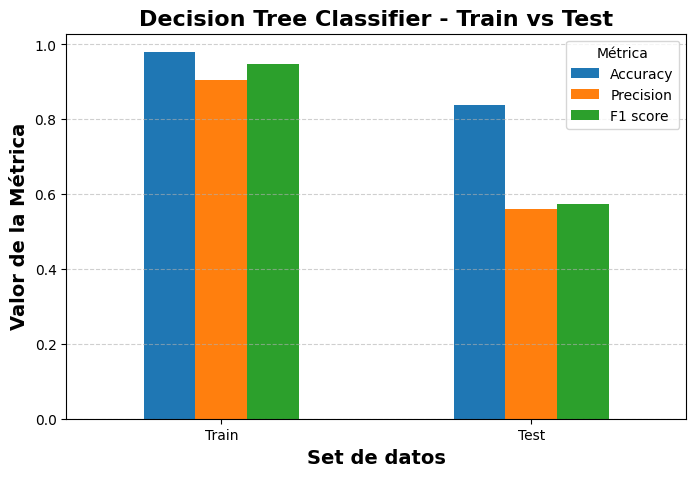

In [ ]:
plt.figure(figsize=(8,5))

ax = resumen_dt.set_index("Dataset").plot(kind="bar", ax=plt.gca())
plt.title("Decision Tree Classifier - Train vs Test", fontsize=16, fontweight="bold")
plt.ylabel("Valor de la Métrica", fontsize=14, fontweight="bold")
plt.xlabel("Set de datos", fontsize=14, fontweight="bold")
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

Interpretaciones

Estos resultados del Decision Tree muestran una gran diferencia entre entrenamiento y prueba: en train el modelo tiene métricas muy altas (Accuracy 0.98 y F1 0.95), lo que indica que aprendió muy bien los datos de entrenamiento, pero en test el rendimiento cae bastante (Accuracy 0.84 y F1 0.57), señal clara de sobreajuste (overfitting). En otras palabras, el árbol memorizó patrones del train, pero no generaliza bien a datos nuevos, especialmente en precisión y F1-score.

###Modelo 3: SVM

Métricas

In [ ]:
# ===== MÉTRICAS EN TEST =====
# Predicciones en test
y_pred_svm = modelo_svm.predict(X_test_svm)
y_proba_svm = modelo_svm.predict_proba(X_test_svm)[:, 1]

# Cálculo de métricas
test_acc_svm = accuracy_score(y_test_svm, y_pred_svm)
test_precision_svm = precision_score(y_test_svm, y_pred_svm)
test_f1_svm = f1_score(y_test_svm, y_pred_svm)

print("=== Métricas en Test ===")
print(f"{'Accuracy en test':<35} : {test_acc_svm:.2f}")
print(f"{'Precisión en test':<35} : {test_precision_svm:.2f}")
print(f"{'F1 score en test':<35} : {test_f1_svm:.2f}")

=== Métricas en Test ===
Accuracy en test                    : 0.68
Precisión en test                   : 0.34
F1 score en test                    : 0.48


In [ ]:
train_pred_svm = modelo_svm.predict(X_train_svm)
train_proba_svm = modelo_svm.predict_proba(X_train_svm)[:, 1]

# Cálculo de métricas
train_acc_svm = accuracy_score(y_train_svm, train_pred_svm)
train_precision_svm = precision_score(y_train_svm, train_pred_svm)
train_f1_svm = f1_score(y_train_svm, train_pred_svm)

print("=== Métricas en Entrenamiento ===")
print(f"{'Accuracy en entrenamiento':<35} : {train_acc_svm:.2f}")
print(f"{'Precisión en entrenamiento':<35} : {train_precision_svm:.2f}")
print(f"{'F1 score en entrenamiento':<35} : {train_f1_svm:.2f}")

=== Métricas en Entrenamiento ===
Accuracy en entrenamiento           : 0.68
Precisión en entrenamiento          : 0.34
F1 score en entrenamiento           : 0.48


In [ ]:
resumen_svm = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_acc_svm, test_acc_svm],
    "Precision": [train_precision_svm, test_precision_svm],
    "F1 score": [train_f1_svm, test_f1_svm]
}).round(4)

display(resumen_svm)

,Dataset,Accuracy,Precision,F1 score
0,Train,0.6786,0.3417,0.4785
1,Test,0.6818,0.3443,0.4811


Gráfico

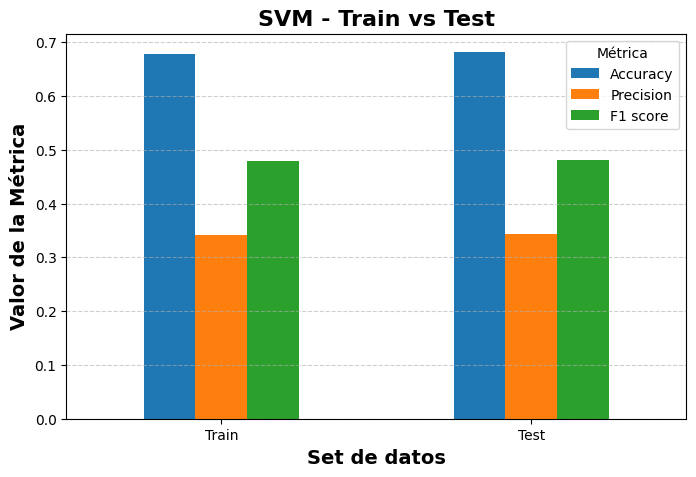

In [ ]:
plt.figure(figsize=(8,5))

ax = resumen_svm.set_index("Dataset").plot(kind="bar", ax=plt.gca())
plt.title("SVM - Train vs Test", fontsize=16, fontweight="bold")
plt.ylabel("Valor de la Métrica", fontsize=14, fontweight="bold")
plt.xlabel("Set de datos", fontsize=14, fontweight="bold")
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

Interpretaciones

Los resultados del SVM muestran un rendimiento bajo pero consistente entre *train* y *test* (accuracy ≈ 0.68 y F1 ≈ 0.48 en ambos), lo que indica que el modelo no está sobreajustado, pero tampoco logra capturar bien los patrones del problema. La similitud de las métricas sugiere que el SVM, con esta configuración, no separa adecuadamente las clases. En este caso, el modelo no se utiliza para predicción final, sino como una herramienta exploratoria para comparar kernels y entender cuál ofrece mejor separación de los datos, sirviendo como referencia para elegir el kernel más adecuado en modelos posteriores.


### 5.1 Selección del mejor modelo

Considerando todos los modelos se va a comparar entre ellos segun el F1-SCORE, debido a que hay un evidente desbalanceo de clases, tanto como el precision, el recall y el accuracy no son suficientes para evaluar los modelos, entonces se opta por el F1-SCORE.

In [ ]:
# Recopilar F1 Scores de todos los modelos
resultados_comparacion = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'SVM', 'Decision Tree'],
    'F1_Train': [train_f1_lr, train_f1_svm, train_f1_dt],
    'F1_Test': [test_f1_lr, test_f1_svm, test_f1_dt],
    'Acurracy_Test': [test_acc_lr, test_acc_svm, test_acc_dt],
    'Presicion_Test': [test_precision_lr, test_precision_svm, test_precision_dt],
})

resultados_comparacion['Diferencia_F1'] = abs(
    resultados_comparacion['F1_Train'] - resultados_comparacion['F1_Test']
)

print(resultados_comparacion.round(4))

                Modelo  F1_Train  F1_Test  Acurracy_Test  Presicion_Test  \
0  Logistic Regression    0.5707   0.5707         0.7719          0.4375   
1                  SVM    0.4785   0.4811         0.6818          0.3443   
2        Decision Tree    0.9480   0.5750         0.8385          0.5598   

   Diferencia_F1  
0         0.0000  
1         0.0026  
2         0.3731  


In [ ]:
# ================================
# RECOPILAR MÉTRICAS
# ================================
resultados_comparacion = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'SVM', 'Decision Tree'],
    'F1_Train': [train_f1_lr, train_f1_svm, train_f1_dt],
    'F1_Test': [test_f1_lr, test_f1_svm, test_f1_dt],
    'Accuracy_Test': [test_acc_lr, test_acc_svm, test_acc_dt],
    'Precision_Test': [test_precision_lr, test_precision_svm, test_precision_dt],
})

# Diferencia entre train y test (overfitting)
resultados_comparacion['Diferencia_F1'] = abs(
    resultados_comparacion['F1_Train'] - resultados_comparacion['F1_Test']
)

print(resultados_comparacion.round(4))

# ================================
# SELECCIÓN DEL MEJOR MODELO
# ================================
UMBRAL_DIFERENCIA_F1 = 0.10  # tolerancia máxima de sobreajuste

# Filtrar modelos que generalizan bien
modelos_validos = resultados_comparacion[
    resultados_comparacion['Diferencia_F1'] <= UMBRAL_DIFERENCIA_F1
]

# Si todos sobreajustan, usar todos (seguridad)
if modelos_validos.empty:
    modelos_validos = resultados_comparacion.copy()

# Elegir el mejor modelo entre los válidos
mejor_idx = modelos_validos['F1_Test'].idxmax()
mejor_modelo_info = resultados_comparacion.loc[mejor_idx]

print(f"\nMejor modelo seleccionado: {mejor_modelo_info['Modelo']}")
print(f"F1 Score (Test): {mejor_modelo_info['F1_Test']:.4f}")
print(f"Accuracy (Test): {mejor_modelo_info['Accuracy_Test']:.4f}")
print(f"Precision (Test): {mejor_modelo_info['Precision_Test']:.4f}")
print(f"Diferencia F1: {mejor_modelo_info['Diferencia_F1']:.4f}")

# ================================
# ASIGNAR MODELO FINAL
# ================================
nombre_mejor = mejor_modelo_info["Modelo"]

if nombre_mejor == "Logistic Regression":
    mejor_modelo = modelo_lr
    y_pred_mejor = y_pred_lr
    y_proba_mejor = y_proba_lr
    X_test_mejor = X_test_lr
    y_test_mejor = y_test_lr

elif nombre_mejor == "SVM":
    mejor_modelo = modelo_svm
    y_pred_mejor = y_pred_svm
    y_proba_mejor = y_proba_svm
    X_test_mejor = X_test_svm
    y_test_mejor = y_test_svm

elif nombre_mejor == "Decision Tree":
    mejor_modelo = mejor_modelo_dt
    y_pred_mejor = y_pred_dt
    y_proba_mejor = y_proba_dt
    X_test_mejor = X_test_dt
    y_test_mejor = y_test_dt


                Modelo  F1_Train  F1_Test  Accuracy_Test  Precision_Test  \
0  Logistic Regression    0.5707   0.5707         0.7719          0.4375   
1                  SVM    0.4785   0.4811         0.6818          0.3443   
2        Decision Tree    0.9480   0.5750         0.8385          0.5598   

   Diferencia_F1  
0         0.0000  
1         0.0026  
2         0.3731  

Mejor modelo seleccionado: Logistic Regression
F1 Score (Test): 0.5707
Accuracy (Test): 0.7719
Precision (Test): 0.4375
Diferencia F1: 0.0000


Gráfico de comparación de todos los modelos

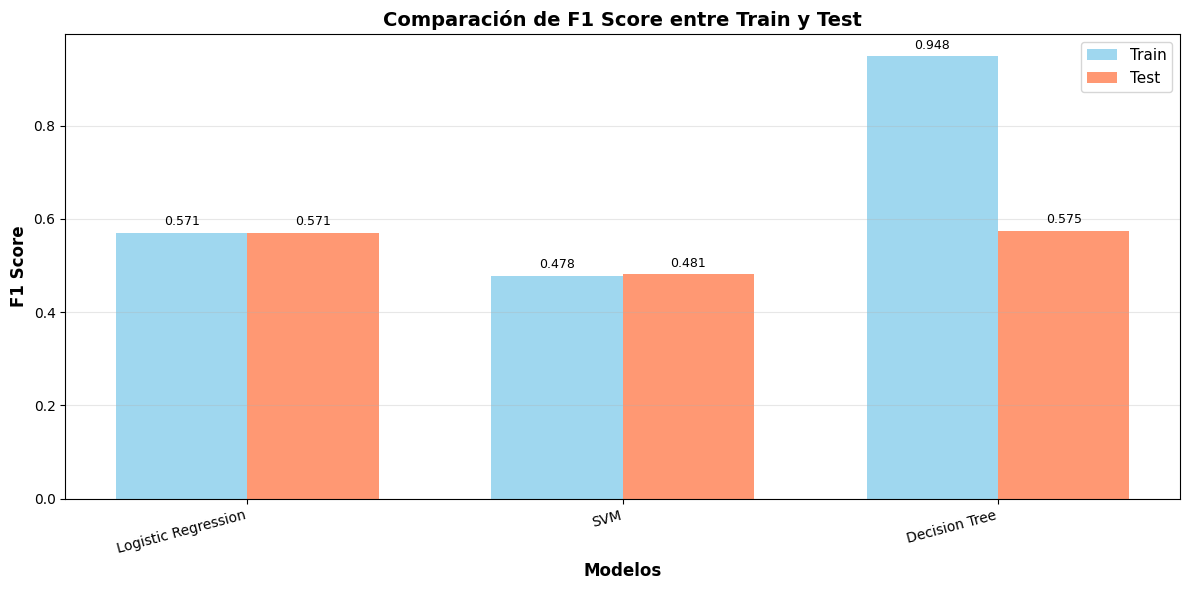

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(resultados_comparacion))
width= 0.35

bars1 = ax.bar(x - width/2, resultados_comparacion['F1_Train'], width, label="Train", color='skyblue', alpha=0.8)
bars2 = ax.bar(x + width/2, resultados_comparacion['F1_Test'], width, label="Test", color='coral', alpha=0.8)

ax.set_xlabel('Modelos', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Comparación de F1 Score entre Train y Test', fontsize=14, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(resultados_comparacion['Modelo'], rotation=15, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
  for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=9)
mejor_x = mejor_idx

plt.tight_layout()
plt.show()

### 5.2 Elección del mejor modelo creado : Logistic Regression

Apreciando este gráfico , se puede evidenciar e inferir que el mejor modelo de entrenamiento, es el Logistic Regression , ya que presenta las mejores métricas al momento de comparar su F1 Score entre su periódo de entrenamiento y testeo, basicamente son igualitarios, lo que significa que puede predecir sin antecedentes de haber memorizado la data, realizando predicciones limpias y con buenas prácticas, pese a tener un F1 Score bajo el 80%, es un modelo compacto que esta entrenado con buenas formas, no está sobreentrenado, y pese al desbalance existente de clases, en su etapa de entrenamiento y testeo logró mantenerse igual a igual

### 5.3 Interpretación de las predicciones en base al mejor modelo seleccionado (Logistic Regression) para el negocio

Desde un punto de vista de negocio, este modelo logra implementar con éxito una herramienta de apoyo a la toma de decisiones que permite anticipar eventos de lluvia a partir de datos climáticos históricos y contextuales. Al generar predicciones y evaluar su acierto en escenarios reales, el modelo ayuda a reducir la incertidumbre operativa, optimizar la planificación de actividades sensibles al clima y disminuir riesgos y costos asociados a cancelaciones, retrasos o accidentes, aportando valor directo a la continuidad y seguridad del negocio , en este caso , el negocio de parapentes podría controlar y tener un margen de mejora exponencial en cuanto a efectividad de sus operaciones.

Interpretación de métricas en relacion al modelo para el negocio:
- Accuracy: Mide qué porcentaje total de las veces el negocio operó correctamente (voló cuando estaba lindo y cerró cuando llovió), reflejando la confiabilidad general de la marca.

- Precision: Indica qué tan efectivas son nuestras cancelaciones; si es baja, estamos perdiendo dinero cancelando vuelos por lluvias que nunca llegan (Costo de Oportunidad).

- F1-score: Es el indicador de sostenibilidad del negocio, ya que resume qué tan bien equilibramos la seguridad de los pasajeros (Recall) con la maximización de ingresos (Precision).

- Recall: Es nuestra métrica de Seguridad Crítica; nos dice si el sistema es capaz de detectar todas las tormentas reales para evitar accidentes fatales en el aire.

- Matriz de confusión: Implementada en el desarrollo del modelo: Es la auditoría operativa que nos muestra exactamente cuánto dinero perdimos por falsas alarmas y cuántos riesgos de seguridad corrimos por tormentas no detectadas.

Cada métrica tiene su definición, pero estos son posibles escenarios en el negoci donde cada métrica puede ayudar en su interpretación, la métrica especial y más importante para este caso es el F1 Score, porque tiene en cuenta el desbalanceo de las clases (el cual es gigante en este caso), y es la variable más representativa para el negocio en base a si llueve o no llueve.


# 6.0 Predicción con el mejor modelo

Aca con el mejor modelo vamos a predecir con datos al azar si es que va a llover o no a cierta hora

In [ ]:
def predecir_fila_aleatoria_pipeline(data, pipeline):
    """
    Predicción usando el modelo LR
    """
    # Seleccionar fila aleatoria
    indice = random.randint(0, len(data) - 1)
    fila = data.iloc[indice]

    # Calcular estadísticas del día
    fecha_dia = pd.to_datetime(fila['date']).date()
    datos_dia = data[data['date'].dt.date == fecha_dia]

    # Preparar datos ORIGINALES (desescalamiento)
    datos_originales = {
        'temperature_2m_mean': datos_dia['temperature_2m'].mean(),
        'temperature_2m_max': datos_dia['temperature_2m'].max(),
        'relative_humidity_2m_mean': datos_dia['relative_humidity_2m'].mean(),
        'relative_humidity_2m_max': datos_dia['relative_humidity_2m'].max(),
        'cloud_cover_mean': datos_dia['cloud_cover'].mean(),
        'cloud_cover_max': datos_dia['cloud_cover'].max(),
        'sunshine_duration_mean': datos_dia['sunshine_duration'].mean(),
        'sunshine_duration_max': datos_dia['sunshine_duration'].max(),
        'apparent_temperature_mean': datos_dia['apparent_temperature'].mean(),
        'apparent_temperature_max': datos_dia['apparent_temperature'].max(),
    }

    # Agregar variables categóricas y cíclicas
    hora = pd.to_datetime(fila['date']).hour
    mes = pd.to_datetime(fila['date']).month

    datos_originales['Localidad_Punta Arenas, Chile'] = 1 if fila['Localidad'] == 'Punta Arenas, Chile' else 0
    datos_originales['Localidad_Temuco, Chile'] = 1 if fila['Localidad'] == 'Temuco, Chile' else 0
    datos_originales['Localidad_Valdivia, Chile'] = 1 if fila['Localidad'] == 'Valdivia, Chile' else 0
    datos_originales['hour_sin'] = np.sin(2 * np.pi * hora / 24)
    datos_originales['hour_cos'] = np.cos(2 * np.pi * hora / 24)
    datos_originales['month_sin'] = np.sin(2 * np.pi * mes / 12)
    datos_originales['month_cos'] = np.cos(2 * np.pi * mes / 12)

    # Crear DataFrame
    columnas_orden = [
        "temperature_2m_mean", "temperature_2m_max",
        "relative_humidity_2m_mean", "relative_humidity_2m_max",
        "cloud_cover_mean", "cloud_cover_max",
        "Localidad_Punta Arenas, Chile",
        "Localidad_Temuco, Chile",
        "Localidad_Valdivia, Chile",
        "hour_sin", "hour_cos",
        "month_sin", "month_cos",
        'sunshine_duration_mean', 'sunshine_duration_max',
        'apparent_temperature_mean', 'apparent_temperature_max',
    ]

    X_prediccion = pd.DataFrame([datos_originales])[columnas_orden]

    # El pipeline escala automáticamente y predice
    prediccion = pipeline.predict(X_prediccion)[0]
    probabilidades = pipeline.predict_proba(X_prediccion)[0]

    acierto = prediccion == fila['is_rainy_hour']

    # Probabilidades
    prob_lluvia = probabilidades[1]

    # Mostrar resultados
    print("="*60)
    print(f"PREDICCION #{indice}")
    print("="*60)
    print(f"Fecha:       {fila['date']}")
    print(f"Localidad:   {fila['Localidad']}")
    print(f"Temperatura: {fila['temperature_2m']:.1f} C")
    print(f"Humedad:     {fila['relative_humidity_2m']:.1f}%")
    print(f"Nubosidad:   {fila['cloud_cover']:.1f}%")
    print("-"*60)
    print(f"PREDICCION: {'LLOVERA' if prediccion == 1 else 'NO LLOVERA'}")
    print(f"REALIDAD:   {'LLOVIO' if fila['is_rainy_hour'] == 1 else 'NO LLOVIO'}")
    print(f"RESULTADO:  {'ACIERTO' if acierto else 'ERROR'}")

    if not acierto:
        # Analizar el tipo de error
        if prediccion == 1 and fila['is_rainy_hour'] == 0:
            print(f"  Tipo: Falso positivo (predijo lluvia, no llovio)")
        else:
            print(f"  Tipo: Falso negativo (predijo no lluvia, llovio)")

    print("="*60)
    print()

    return {
        'indice': indice,
        'prediccion': prediccion,
        'probabilidad_lluvia': prob_lluvia,
        'real': fila['is_rainy_hour'],
        'acierto': acierto
    }


# Ejecutar múltiples predicciones y ver estadísticas
print("### 5 PREDICCIONES CON PIPELINE ###\n")

resultados = []
for i in range(5):
    resultado = predecir_fila_aleatoria_pipeline(data, modelo_lr)
    resultados.append(resultado)

### 5 PREDICCIONES CON PIPELINE ###

PREDICCION #24352
Fecha:       2025-11-23 19:00:00+00:00
Localidad:   Temuco, Chile
Temperatura: 24.3 C
Humedad:     57.8%
Nubosidad:   0.0%
------------------------------------------------------------
PREDICCION: LLOVERA
REALIDAD:   NO LLOVIO
RESULTADO:  ERROR
  Tipo: Falso positivo (predijo lluvia, no llovio)

PREDICCION #20574
Fecha:       2025-06-19 09:00:00+00:00
Localidad:   Temuco, Chile
Temperatura: 1.5 C
Humedad:     90.4%
Nubosidad:   0.0%
------------------------------------------------------------
PREDICCION: NO LLOVERA
REALIDAD:   NO LLOVIO
RESULTADO:  ACIERTO

PREDICCION #29534
Fecha:       2025-07-18 17:00:00+00:00
Localidad:   Valdivia, Chile
Temperatura: 9.6 C
Humedad:     86.5%
Nubosidad:   100.0%
------------------------------------------------------------
PREDICCION: NO LLOVERA
REALIDAD:   NO LLOVIO
RESULTADO:  ACIERTO

PREDICCION #30068
Fecha:       2025-08-09 23:00:00+00:00
Localidad:   Valdivia, Chile
Temperatura: 8.7 C
Humeda